# 02 — Time-Domain Encoding & the PB-1 TTS Chip (v5, v6, v7, v10-RC)
*Requires: `apt-get install espeak-ng mbrola mbrola-us1` (Ubuntu archive).*

**Contents:** latency/encoding study (one-hot input, continuous chaining,
first-spike WTA); legacy formant chip (v6); definitive LPC-10/MBROLA chip
with per-chip head calibration (v7); RC-causal printed-passive context
variant (v10); die-viewer builder (needs v7 outputs present).
Audio outputs: v7_mbrola_original / v7_vocoder_ceiling / v7_chip_{A,B} /
v7_chip_A_drifted / v10_chip_RC_causal (.wav) + chip_viewer.html.
Key findings: F10, F11, F12, F12b.

In [ ]:
%%writefile time_domain_sim_v5.py
"""
time_domain_sim_v5.py — addressing the 2^N PWM latency.

The 2^N latency exists only where a DIGITAL value must be serialized into
unit time slots. Three places it could appear, and the countermeasure
simulated for each:

  INPUT layer   -> one-hot binary lines (Avery's scheme): every line is
                   full-on for exactly 1 unit slot or off. Latency = 1 slot,
                   input timing precision requirement = none.
  HIDDEN layers -> continuous pulse chaining: integrator+comparator turns
                   column charge back into a pulse WIDTH (never a digital
                   code), so there is no 2^N grid at all. The per-layer
                   window T is a free knob; the effective resolution is
                   R = T / sigma_t (window over timing jitter). We sweep R
                   to find how few distinguishable levels the task really
                   needs — that ratio vs 256 (8-bit) is the latency saving.
  OUTPUT layer  -> first-spike winner-take-all: each class charges a cap at
                   a rate ~ its logit; first comparator to fire IS argmax.
                   Decision time is data-dependent (confident inputs finish
                   early) and no output window must complete.

Noise model (consistent with v1/v4): baked weights x(1+N(0,5%)) once;
timing jitter N(0, sigma_t) added to every pulse width at every stage,
parameterized as R = T/sigma_t; input quantized to its slot count.

Tasks:
  A. sklearn digits, MLP 64-48-24-10 (established project baselines),
     input = 16-slot PWM (pixels are 4-bit already).
  B. talking-clock words: 27 one-hot lines x 9 positions = 243 binary
     inputs, vocabulary of 24 time words with typo noise. MLP 243-64-32-24.
     Deployment shift = one-position text shift (leading space), fine-tune
     output layer only (the baked-encoder + tunable-head split).
"""
import numpy as np, csv, time, json

rng_global = np.random.default_rng
SIGMA_FAB = 0.05
relu = lambda x: np.maximum(0, x)

def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True)); return e / e.sum(axis=1, keepdims=True)

class MLP:
    def __init__(self, sizes, rng):
        self.sizes = sizes
        self.W = [rng.normal(0, np.sqrt(2 / sizes[i]), (sizes[i], sizes[i + 1]))
                  for i in range(len(sizes) - 1)]
        self.b = [np.zeros(sizes[i + 1]) for i in range(len(sizes) - 1)]
    def forward(self, X):
        a = [X]
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = a[-1] @ W + b
            a.append(relu(z) if i < len(self.W) - 1 else z)
        return a
    def train(self, X, y, epochs, lr, rng, train_layers=None):
        n = len(X)
        for _ in range(epochs):
            idx = rng.permutation(n)
            for s in range(0, n, 32):
                bi = idx[s:s + 32]
                a = self.forward(X[bi])
                p = softmax(a[-1]); Y = np.eye(p.shape[1])[y[bi]]
                delta = (p - Y) / len(bi)
                for i in reversed(range(len(self.W))):
                    gW = a[i].T @ delta; gb = delta.sum(axis=0)
                    if i > 0:
                        delta = (delta @ self.W[i].T) * (a[i] > 0)
                    if train_layers is None or i in train_layers:
                        self.W[i] -= lr * gW; self.b[i] -= lr * gb
    def acc(self, X, y):
        return (self.forward(X)[-1].argmax(axis=1) == y).mean()

# ---------------- time-domain chained forward ----------------
def calibrate(model, X):
    """Per-layer activation ceilings (window scale), design-time, ex-situ."""
    a = model.forward(X)
    return [np.percentile(h, 99.5) for h in a[1:-1]] + [None]

def td_forward(model, X, R, rng, ceilings, input_slots=None, w_noise=None,
               first_spike=False, R_out=None):
    """
    R: per-hidden-layer distinguishable levels (window / jitter sd).
    input_slots: PWM slot count for analog input (None = binary/one-hot,
                 already exact, jitter irrelevant because full-window pulses
                 land on a shared clock edge).
    Returns (correct_bool_array, decision_time_fraction or None).
    """
    Wn = w_noise if w_noise is not None else [
        W * (1 + rng.normal(0, SIGMA_FAB, W.shape)) for W in model.W]
    a = X.copy()
    if input_slots is not None:  # analog input PWM-quantized + jittered
        amax = a.max() + 1e-12
        a = np.round(a / amax * input_slots) / input_slots * amax
        a = a + rng.normal(0, amax / R, a.shape)   # driver jitter
        a = np.clip(a, 0, amax)
    for i, (W, b) in enumerate(zip(Wn, model.b)):
        z = a @ W + b
        if i < len(Wn) - 1:
            c = ceilings[i]
            a = relu(z)
            a = a + rng.normal(0, c / R, a.shape)   # integrator->pulse jitter
            a = np.clip(a, 0, c)                    # window saturation
        else:
            z_out = z
    if not first_spike:
        return z_out.argmax(axis=1), None
    # first-spike WTA: I_j = z_j + B > 0, t_j = K/I_j, jittered crossing
    B = -z_out.min() + 0.25 * (z_out.max() - z_out.min()) + 1e-9
    I = z_out + B
    t = 1.0 / I
    Rw = R_out or R
    t = t * (1 + rng.normal(0, 1.0 / Rw, t.shape))
    pred = t.argmin(axis=1)
    t_win = t.min(axis=1); t_ref = 1.0 / B      # window = zero-signal neuron
    return pred, (t_win / t_ref)

# ---------------- Task A: digits ----------------
def task_digits():
    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split
    X, y = load_digits(return_X_y=True)
    return train_test_split(X / 16.0, y, test_size=0.35, random_state=42, stratify=y)

# ---------------- Task B: talking-clock words ----------------
VOCAB = ["one","two","three","four","five","six","seven","eight","nine","ten",
         "eleven","twelve","oclock","half","quarter","past","to","thirty",
         "fifteen","twenty","forty","midnight","noon","am"]
ALPHA = "abcdefghijklmnopqrstuvwxyz "   # 27 symbols
L = 9

def encode(word, shift=0):
    w = (" " * shift + word)[:L].ljust(L)
    v = np.zeros((L, len(ALPHA)))
    for p, ch in enumerate(w):
        v[p, ALPHA.index(ch)] = 1.0
    return v.ravel()

def make_clock_data(n, rng, typo=0.05, shift=0):
    X = np.zeros((n, L * len(ALPHA))); y = np.zeros(n, dtype=int)
    for k in range(n):
        wi = rng.integers(len(VOCAB)); word = VOCAB[wi]
        chars = list(word)
        for p in range(len(chars)):
            if rng.random() < typo:
                chars[p] = ALPHA[rng.integers(26)]
        X[k] = encode("".join(chars), shift); y[k] = wi
    return X, y

# ---------------- experiments ----------------
if __name__ == "__main__":
    t0 = time.time(); rows = []
    R_GRID = [2, 4, 8, 16, 32, 64, 128, 256]
    N_SEEDS, N_MC = 5, 8

    # ===== A: digits, PWM-16 input + chained hidden layers =====
    Xtr, Xte, ytr, yte = task_digits()
    for seed in range(N_SEEDS):
        rng = rng_global(seed)
        m = MLP([64, 48, 24, 10], rng); m.train(Xtr, ytr, 300, 0.05, rng)
        ceil = calibrate(m, Xtr)
        float_acc = m.acc(Xte, yte)
        rows.append(dict(task="digits", kind="float", seed=seed, R=np.inf,
                         acc=round(float_acc, 4), dec_time=""))
        for R in R_GRID:
            for mc in range(N_MC):
                r2 = rng_global(10000 + 100 * seed + mc)
                wn = [W * (1 + r2.normal(0, SIGMA_FAB, W.shape)) for W in m.W]
                pred, _ = td_forward(m, Xte, R, r2, ceil, input_slots=16, w_noise=wn)
                rows.append(dict(task="digits", kind="td_pwm16", seed=seed, R=R,
                                 acc=round((pred == yte).mean(), 4), dec_time=""))
                pred, dt = td_forward(m, Xte, R, r2, ceil, input_slots=16,
                                      w_noise=wn, first_spike=True)
                rows.append(dict(task="digits", kind="td_pwm16_fs", seed=seed, R=R,
                                 acc=round((pred == yte).mean(), 4),
                                 dec_time=round(float(np.mean(dt)), 4)))
        print(f"A seed {seed} done {time.time()-t0:.0f}s", flush=True)

    # ===== B: clock words, one-hot binary input =====
    for seed in range(N_SEEDS):
        rng = rng_global(500 + seed)
        Xtr2, ytr2 = make_clock_data(4000, rng, typo=0.05)
        Xte2, yte2 = make_clock_data(1200, rng_global(900 + seed), typo=0.05)
        Xsh, ysh = make_clock_data(1200, rng_global(901 + seed), typo=0.05, shift=1)
        Xad, yad = make_clock_data(200, rng_global(902 + seed), typo=0.05, shift=1)
        m = MLP([L * len(ALPHA), 64, 32, len(VOCAB)], rng)
        m.train(Xtr2, ytr2, 60, 0.05, rng)
        ceil = calibrate(m, Xtr2)
        rows.append(dict(task="clock", kind="float", seed=seed, R=np.inf,
                         acc=round(m.acc(Xte2, yte2), 4), dec_time=""))
        for R in R_GRID:
            for mc in range(N_MC):
                r2 = rng_global(20000 + 100 * seed + mc)
                wn = [W * (1 + r2.normal(0, SIGMA_FAB, W.shape)) for W in m.W]
                pred, _ = td_forward(m, Xte2, R, r2, ceil, input_slots=None, w_noise=wn)
                rows.append(dict(task="clock", kind="td_onehot", seed=seed, R=R,
                                 acc=round((pred == yte2).mean(), 4), dec_time=""))
                pred, dt = td_forward(m, Xte2, R, r2, ceil, input_slots=None,
                                      w_noise=wn, first_spike=True)
                rows.append(dict(task="clock", kind="td_onehot_fs", seed=seed, R=R,
                                 acc=round((pred == yte2).mean(), 4),
                                 dec_time=round(float(np.mean(dt)), 4)))
        # shift adaptation: baked encoder+core, tunable OUTPUT layer only
        r2 = rng_global(30000 + seed)
        wn = [W * (1 + r2.normal(0, SIGMA_FAB, W.shape)) for W in m.W]
        pred, _ = td_forward(m, Xsh, 32, r2, ceil, w_noise=wn)
        pre = (pred == ysh).mean()
        m2 = MLP(m.sizes, rng); m2.W = [w.copy() for w in wn]; m2.b = [b.copy() for b in m.b]
        m2.train(Xad, yad, 80, 0.05, rng, train_layers={2})
        pred, _ = td_forward(m2, Xsh, 32, rng_global(40000 + seed), ceil,
                             w_noise=m2.W)
        post = (pred == ysh).mean()
        rows.append(dict(task="clock_shift", kind="pre", seed=seed, R=32,
                         acc=round(pre, 4), dec_time=""))
        rows.append(dict(task="clock_shift", kind="post_outputFT", seed=seed, R=32,
                         acc=round(post, 4), dec_time=""))
        print(f"B seed {seed} done {time.time()-t0:.0f}s", flush=True)

    with open("results_v5_timedomain.csv", "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print("saved", len(rows), "rows", f"{time.time()-t0:.0f}s")


In [ ]:
%%writefile results_v5_timedomain.csv
task,kind,seed,R,acc,dec_time
digits,float,0,inf,0.9666,
digits,td_pwm16,0,2,0.1606,
digits,td_pwm16_fs,0,2,0.097,0.2321
digits,td_pwm16,0,2,0.1351,
digits,td_pwm16_fs,0,2,0.1065,0.2331
digits,td_pwm16,0,2,0.1431,
digits,td_pwm16_fs,0,2,0.0827,0.232
digits,td_pwm16,0,2,0.1638,
digits,td_pwm16_fs,0,2,0.1002,0.2175
digits,td_pwm16,0,2,0.1447,
digits,td_pwm16_fs,0,2,0.1033,0.2432
digits,td_pwm16,0,2,0.1367,
digits,td_pwm16_fs,0,2,0.1081,0.2102
digits,td_pwm16,0,2,0.1463,
digits,td_pwm16_fs,0,2,0.1161,0.2281
digits,td_pwm16,0,2,0.1669,
digits,td_pwm16_fs,0,2,0.1081,0.2107
digits,td_pwm16,0,4,0.3577,
digits,td_pwm16_fs,0,4,0.1685,0.5966
digits,td_pwm16,0,4,0.337,
digits,td_pwm16_fs,0,4,0.1844,0.5917
digits,td_pwm16,0,4,0.3736,
digits,td_pwm16_fs,0,4,0.132,0.6
digits,td_pwm16,0,4,0.3386,
digits,td_pwm16_fs,0,4,0.1717,0.5764
digits,td_pwm16,0,4,0.3196,
digits,td_pwm16_fs,0,4,0.159,0.6015
digits,td_pwm16,0,4,0.3545,
digits,td_pwm16_fs,0,4,0.1526,0.5828
digits,td_pwm16,0,4,0.337,
digits,td_pwm16_fs,0,4,0.1669,0.5856
digits,td_pwm16,0,4,0.3641,
digits,td_pwm16_fs,0,4,0.1669,0.5791
digits,td_pwm16,0,8,0.7234,
digits,td_pwm16_fs,0,8,0.4165,0.7385
digits,td_pwm16,0,8,0.752,
digits,td_pwm16_fs,0,8,0.3943,0.738
digits,td_pwm16,0,8,0.7599,
digits,td_pwm16_fs,0,8,0.3148,0.7632
digits,td_pwm16,0,8,0.7122,
digits,td_pwm16_fs,0,8,0.4245,0.7313
digits,td_pwm16,0,8,0.6884,
digits,td_pwm16_fs,0,8,0.4293,0.7418
digits,td_pwm16,0,8,0.7059,
digits,td_pwm16_fs,0,8,0.3498,0.7454
digits,td_pwm16,0,8,0.7313,
digits,td_pwm16_fs,0,8,0.4197,0.7335
digits,td_pwm16,0,8,0.7552,
digits,td_pwm16_fs,0,8,0.3768,0.7347
digits,td_pwm16,0,16,0.9316,
digits,td_pwm16_fs,0,16,0.7758,0.7631
digits,td_pwm16,0,16,0.9348,
digits,td_pwm16_fs,0,16,0.7647,0.7743
digits,td_pwm16,0,16,0.9269,
digits,td_pwm16_fs,0,16,0.7202,0.8018
digits,td_pwm16,0,16,0.9014,
digits,td_pwm16_fs,0,16,0.7568,0.7646
digits,td_pwm16,0,16,0.911,
digits,td_pwm16_fs,0,16,0.7504,0.7679
digits,td_pwm16,0,16,0.9221,
digits,td_pwm16_fs,0,16,0.7488,0.7816
digits,td_pwm16,0,16,0.9205,
digits,td_pwm16_fs,0,16,0.7568,0.7659
digits,td_pwm16,0,16,0.9173,
digits,td_pwm16_fs,0,16,0.7488,0.7759
digits,td_pwm16,0,32,0.965,
digits,td_pwm16_fs,0,32,0.9348,0.7683
digits,td_pwm16,0,32,0.965,
digits,td_pwm16_fs,0,32,0.9348,0.7695
digits,td_pwm16,0,32,0.9523,
digits,td_pwm16_fs,0,32,0.9221,0.7938
digits,td_pwm16,0,32,0.9396,
digits,td_pwm16_fs,0,32,0.9269,0.7627
digits,td_pwm16,0,32,0.9459,
digits,td_pwm16_fs,0,32,0.9094,0.7625
digits,td_pwm16,0,32,0.9539,
digits,td_pwm16_fs,0,32,0.9396,0.7746
digits,td_pwm16,0,32,0.9587,
digits,td_pwm16_fs,0,32,0.9285,0.7616
digits,td_pwm16,0,32,0.9475,
digits,td_pwm16_fs,0,32,0.911,0.7764
digits,td_pwm16,0,64,0.965,
digits,td_pwm16_fs,0,64,0.9539,0.7695
digits,td_pwm16,0,64,0.9714,
digits,td_pwm16_fs,0,64,0.9603,0.7634
digits,td_pwm16,0,64,0.965,
digits,td_pwm16_fs,0,64,0.9539,0.785
digits,td_pwm16,0,64,0.9507,
digits,td_pwm16_fs,0,64,0.9507,0.7588
digits,td_pwm16,0,64,0.9539,
digits,td_pwm16_fs,0,64,0.9459,0.7587
digits,td_pwm16,0,64,0.965,
digits,td_pwm16_fs,0,64,0.9587,0.7715
digits,td_pwm16,0,64,0.9666,
digits,td_pwm16_fs,0,64,0.9587,0.7612
digits,td_pwm16,0,64,0.9603,
digits,td_pwm16_fs,0,64,0.9555,0.7746
digits,td_pwm16,0,128,0.965,
digits,td_pwm16_fs,0,128,0.9603,0.7699
digits,td_pwm16,0,128,0.9698,
digits,td_pwm16_fs,0,128,0.9666,0.7601
digits,td_pwm16,0,128,0.9618,
digits,td_pwm16_fs,0,128,0.9571,0.7802
digits,td_pwm16,0,128,0.9603,
digits,td_pwm16_fs,0,128,0.9618,0.7567
digits,td_pwm16,0,128,0.9571,
digits,td_pwm16_fs,0,128,0.9459,0.7568
digits,td_pwm16,0,128,0.965,
digits,td_pwm16_fs,0,128,0.9634,0.7702
digits,td_pwm16,0,128,0.9666,
digits,td_pwm16_fs,0,128,0.9634,0.7608
digits,td_pwm16,0,128,0.965,
digits,td_pwm16_fs,0,128,0.9634,0.7734
digits,td_pwm16,0,256,0.9634,
digits,td_pwm16_fs,0,256,0.9666,0.77
digits,td_pwm16,0,256,0.9698,
digits,td_pwm16_fs,0,256,0.9682,0.7584
digits,td_pwm16,0,256,0.9618,
digits,td_pwm16_fs,0,256,0.9634,0.7777
digits,td_pwm16,0,256,0.965,
digits,td_pwm16_fs,0,256,0.965,0.7556
digits,td_pwm16,0,256,0.9571,
digits,td_pwm16_fs,0,256,0.9523,0.7558
digits,td_pwm16,0,256,0.9666,
digits,td_pwm16_fs,0,256,0.965,0.7695
digits,td_pwm16,0,256,0.9666,
digits,td_pwm16_fs,0,256,0.965,0.7605
digits,td_pwm16,0,256,0.9666,
digits,td_pwm16_fs,0,256,0.9634,0.7727
digits,float,1,inf,0.9634,
digits,td_pwm16,1,2,0.1669,
digits,td_pwm16_fs,1,2,0.1097,0.2323
digits,td_pwm16,1,2,0.1463,
digits,td_pwm16_fs,1,2,0.1208,0.225
digits,td_pwm16,1,2,0.1558,
digits,td_pwm16_fs,1,2,0.1065,0.2363
digits,td_pwm16,1,2,0.1781,
digits,td_pwm16_fs,1,2,0.1097,0.2207
digits,td_pwm16,1,2,0.1494,
digits,td_pwm16_fs,1,2,0.1081,0.2348
digits,td_pwm16,1,2,0.1749,
digits,td_pwm16_fs,1,2,0.0906,0.2239
digits,td_pwm16,1,2,0.1447,
digits,td_pwm16_fs,1,2,0.1017,0.2333
digits,td_pwm16,1,2,0.151,
digits,td_pwm16_fs,1,2,0.1113,0.2332
digits,td_pwm16,1,4,0.3927,
digits,td_pwm16_fs,1,4,0.2162,0.5871
digits,td_pwm16,1,4,0.4102,
digits,td_pwm16_fs,1,4,0.2321,0.581
digits,td_pwm16,1,4,0.4181,
digits,td_pwm16_fs,1,4,0.186,0.5911
digits,td_pwm16,1,4,0.4118,
digits,td_pwm16_fs,1,4,0.1971,0.583
digits,td_pwm16,1,4,0.3975,
digits,td_pwm16_fs,1,4,0.2019,0.5891
digits,td_pwm16,1,4,0.3895,
digits,td_pwm16_fs,1,4,0.1828,0.5878
digits,td_pwm16,1,4,0.3975,
digits,td_pwm16_fs,1,4,0.2178,0.5802
digits,td_pwm16,1,4,0.3911,
digits,td_pwm16_fs,1,4,0.2019,0.585
digits,td_pwm16,1,8,0.7583,
digits,td_pwm16_fs,1,8,0.4928,0.7189
digits,td_pwm16,1,8,0.7679,
digits,td_pwm16_fs,1,8,0.5755,0.6882
digits,td_pwm16,1,8,0.7727,
digits,td_pwm16_fs,1,8,0.4754,0.7215
digits,td_pwm16,1,8,0.787,
digits,td_pwm16_fs,1,8,0.5135,0.7029
digits,td_pwm16,1,8,0.7631,
digits,td_pwm16_fs,1,8,0.5072,0.711
digits,td_pwm16,1,8,0.7536,
digits,td_pwm16_fs,1,8,0.5215,0.7062
digits,td_pwm16,1,8,0.7822,
digits,td_pwm16_fs,1,8,0.5151,0.6943
digits,td_pwm16,1,8,0.7758,
digits,td_pwm16_fs,1,8,0.4944,0.7148
digits,td_pwm16,1,16,0.903,
digits,td_pwm16_fs,1,16,0.8362,0.7403
digits,td_pwm16,1,16,0.9285,
digits,td_pwm16_fs,1,16,0.8776,0.6966
digits,td_pwm16,1,16,0.9332,
digits,td_pwm16_fs,1,16,0.8474,0.7178
digits,td_pwm16,1,16,0.9221,
digits,td_pwm16_fs,1,16,0.8537,0.7228
digits,td_pwm16,1,16,0.9189,
digits,td_pwm16_fs,1,16,0.8203,0.7155
digits,td_pwm16,1,16,0.9014,
digits,td_pwm16_fs,1,16,0.8394,0.7119
digits,td_pwm16,1,16,0.9189,
digits,td_pwm16_fs,1,16,0.8585,0.7034
digits,td_pwm16,1,16,0.93,
digits,td_pwm16_fs,1,16,0.8362,0.7248
digits,td_pwm16,1,32,0.9396,
digits,td_pwm16_fs,1,32,0.9237,0.73
digits,td_pwm16,1,32,0.9539,
digits,td_pwm16_fs,1,32,0.9571,0.6981
digits,td_pwm16,1,32,0.9555,
digits,td_pwm16_fs,1,32,0.9459,0.7057
digits,td_pwm16,1,32,0.9428,
digits,td_pwm16_fs,1,32,0.9364,0.7188
digits,td_pwm16,1,32,0.9428,
digits,td_pwm16_fs,1,32,0.9285,0.7095
digits,td_pwm16,1,32,0.9507,
digits,td_pwm16_fs,1,32,0.9332,0.707
digits,td_pwm16,1,32,0.9539,
digits,td_pwm16_fs,1,32,0.93,0.6992
digits,td_pwm16,1,32,0.9555,
digits,td_pwm16_fs,1,32,0.9253,0.7182
digits,td_pwm16,1,64,0.9571,
digits,td_pwm16_fs,1,64,0.9459,0.7213
digits,td_pwm16,1,64,0.9555,
digits,td_pwm16_fs,1,64,0.965,0.7001
digits,td_pwm16,1,64,0.9603,
digits,td_pwm16_fs,1,64,0.9587,0.7067
digits,td_pwm16,1,64,0.9539,
digits,td_pwm16_fs,1,64,0.9555,0.7188
digits,td_pwm16,1,64,0.9539,
digits,td_pwm16_fs,1,64,0.9507,0.7065
digits,td_pwm16,1,64,0.9555,
digits,td_pwm16_fs,1,64,0.9475,0.7025
digits,td_pwm16,1,64,0.9571,
digits,td_pwm16_fs,1,64,0.9507,0.6987
digits,td_pwm16,1,64,0.9603,
digits,td_pwm16_fs,1,64,0.9571,0.7125
digits,td_pwm16,1,128,0.9587,
digits,td_pwm16_fs,1,128,0.9539,0.7165
digits,td_pwm16,1,128,0.9555,
digits,td_pwm16_fs,1,128,0.9634,0.7011
digits,td_pwm16,1,128,0.9603,
digits,td_pwm16_fs,1,128,0.9634,0.707
digits,td_pwm16,1,128,0.9571,
digits,td_pwm16_fs,1,128,0.9539,0.7187
digits,td_pwm16,1,128,0.9555,
digits,td_pwm16_fs,1,128,0.9571,0.7047
digits,td_pwm16,1,128,0.9571,
digits,td_pwm16_fs,1,128,0.9539,0.6993
digits,td_pwm16,1,128,0.9571,
digits,td_pwm16_fs,1,128,0.9539,0.6997
digits,td_pwm16,1,128,0.9603,
digits,td_pwm16_fs,1,128,0.9603,0.7092
digits,td_pwm16,1,256,0.9571,
digits,td_pwm16_fs,1,256,0.9539,0.714
digits,td_pwm16,1,256,0.9587,
digits,td_pwm16_fs,1,256,0.9603,0.7015
digits,td_pwm16,1,256,0.9618,
digits,td_pwm16_fs,1,256,0.9634,0.7069
digits,td_pwm16,1,256,0.9523,
digits,td_pwm16_fs,1,256,0.9555,0.7186
digits,td_pwm16,1,256,0.9539,
digits,td_pwm16_fs,1,256,0.9571,0.7038
digits,td_pwm16,1,256,0.9555,
digits,td_pwm16_fs,1,256,0.9539,0.6992
digits,td_pwm16,1,256,0.9571,
digits,td_pwm16_fs,1,256,0.9555,0.7002
digits,td_pwm16,1,256,0.9618,
digits,td_pwm16_fs,1,256,0.9603,0.7075
digits,float,2,inf,0.9682,
digits,td_pwm16,2,2,0.1653,
digits,td_pwm16_fs,2,2,0.1033,0.2171
digits,td_pwm16,2,2,0.1701,
digits,td_pwm16_fs,2,2,0.1161,0.2303
digits,td_pwm16,2,2,0.1924,
digits,td_pwm16_fs,2,2,0.1176,0.2186
digits,td_pwm16,2,2,0.1399,
digits,td_pwm16_fs,2,2,0.1145,0.2347
digits,td_pwm16,2,2,0.1638,
digits,td_pwm16_fs,2,2,0.1161,0.2177
digits,td_pwm16,2,2,0.186,
digits,td_pwm16_fs,2,2,0.0668,0.2195
digits,td_pwm16,2,2,0.1526,
digits,td_pwm16_fs,2,2,0.1065,0.2337
digits,td_pwm16,2,2,0.151,
digits,td_pwm16_fs,2,2,0.124,0.2149
digits,td_pwm16,2,4,0.3752,
digits,td_pwm16_fs,2,4,0.2226,0.5863
digits,td_pwm16,2,4,0.3895,
digits,td_pwm16_fs,2,4,0.2258,0.5862
digits,td_pwm16,2,4,0.4118,
digits,td_pwm16_fs,2,4,0.2035,0.5828
digits,td_pwm16,2,4,0.3847,
digits,td_pwm16_fs,2,4,0.2385,0.5972
digits,td_pwm16,2,4,0.4006,
digits,td_pwm16_fs,2,4,0.2146,0.5905
digits,td_pwm16,2,4,0.4181,
digits,td_pwm16_fs,2,4,0.1765,0.5892
digits,td_pwm16,2,4,0.4022,
digits,td_pwm16_fs,2,4,0.1971,0.5943
digits,td_pwm16,2,4,0.4213,
digits,td_pwm16_fs,2,4,0.2035,0.5856
digits,td_pwm16,2,8,0.7965,
digits,td_pwm16_fs,2,8,0.5644,0.708
digits,td_pwm16,2,8,0.7742,
digits,td_pwm16_fs,2,8,0.5612,0.6999
digits,td_pwm16,2,8,0.7679,
digits,td_pwm16_fs,2,8,0.4944,0.7208
digits,td_pwm16,2,8,0.7663,
digits,td_pwm16_fs,2,8,0.5358,0.7221
digits,td_pwm16,2,8,0.7647,
digits,td_pwm16_fs,2,8,0.5087,0.7254
digits,td_pwm16,2,8,0.7917,
digits,td_pwm16_fs,2,8,0.5199,0.7216
digits,td_pwm16,2,8,0.7631,
digits,td_pwm16_fs,2,8,0.4801,0.733
digits,td_pwm16,2,8,0.7917,
digits,td_pwm16_fs,2,8,0.5517,0.7095
digits,td_pwm16,2,16,0.9348,
digits,td_pwm16_fs,2,16,0.8665,0.7167
digits,td_pwm16,2,16,0.9078,
digits,td_pwm16_fs,2,16,0.8521,0.7153
digits,td_pwm16,2,16,0.9173,
digits,td_pwm16_fs,2,16,0.8378,0.7383
digits,td_pwm16,2,16,0.9237,
digits,td_pwm16_fs,2,16,0.876,0.7218
digits,td_pwm16,2,16,0.9237,
digits,td_pwm16_fs,2,16,0.8601,0.7337
digits,td_pwm16,2,16,0.9269,
digits,td_pwm16_fs,2,16,0.8521,0.7248
digits,td_pwm16,2,16,0.9205,
digits,td_pwm16_fs,2,16,0.8521,0.7379
digits,td_pwm16,2,16,0.9412,
digits,td_pwm16_fs,2,16,0.8617,0.7198
digits,td_pwm16,2,32,0.965,
digits,td_pwm16_fs,2,32,0.9444,0.714
digits,td_pwm16,2,32,0.9507,
digits,td_pwm16_fs,2,32,0.9412,0.712
digits,td_pwm16,2,32,0.9491,
digits,td_pwm16_fs,2,32,0.93,0.7252
digits,td_pwm16,2,32,0.9539,
digits,td_pwm16_fs,2,32,0.9459,0.7043
digits,td_pwm16,2,32,0.9555,
digits,td_pwm16_fs,2,32,0.9396,0.7235
digits,td_pwm16,2,32,0.9523,
digits,td_pwm16_fs,2,32,0.9459,0.7112
digits,td_pwm16,2,32,0.9475,
digits,td_pwm16_fs,2,32,0.9571,0.7227
digits,td_pwm16,2,32,0.9587,
digits,td_pwm16_fs,2,32,0.9555,0.7135
digits,td_pwm16,2,64,0.9634,
digits,td_pwm16_fs,2,64,0.9634,0.7112
digits,td_pwm16,2,64,0.9634,
digits,td_pwm16_fs,2,64,0.9555,0.7088
digits,td_pwm16,2,64,0.9571,
digits,td_pwm16_fs,2,64,0.9555,0.7176
digits,td_pwm16,2,64,0.965,
digits,td_pwm16_fs,2,64,0.9618,0.7016
digits,td_pwm16,2,64,0.9603,
digits,td_pwm16_fs,2,64,0.9603,0.721
digits,td_pwm16,2,64,0.9618,
digits,td_pwm16_fs,2,64,0.9603,0.7077
digits,td_pwm16,2,64,0.965,
digits,td_pwm16_fs,2,64,0.9587,0.7136
digits,td_pwm16,2,64,0.9634,
digits,td_pwm16_fs,2,64,0.9603,0.7119
digits,td_pwm16,2,128,0.965,
digits,td_pwm16_fs,2,128,0.965,0.7099
digits,td_pwm16,2,128,0.9634,
digits,td_pwm16_fs,2,128,0.9618,0.7099
digits,td_pwm16,2,128,0.9618,
digits,td_pwm16_fs,2,128,0.9587,0.7152
digits,td_pwm16,2,128,0.9618,
digits,td_pwm16_fs,2,128,0.9618,0.7017
digits,td_pwm16,2,128,0.9603,
digits,td_pwm16_fs,2,128,0.9571,0.7197
digits,td_pwm16,2,128,0.9634,
digits,td_pwm16_fs,2,128,0.9634,0.7069
digits,td_pwm16,2,128,0.965,
digits,td_pwm16_fs,2,128,0.9618,0.7105
digits,td_pwm16,2,128,0.965,
digits,td_pwm16_fs,2,128,0.9634,0.7116
digits,td_pwm16,2,256,0.9634,
digits,td_pwm16_fs,2,256,0.9666,0.7091
digits,td_pwm16,2,256,0.9603,
digits,td_pwm16_fs,2,256,0.9618,0.7107
digits,td_pwm16,2,256,0.9603,
digits,td_pwm16_fs,2,256,0.9587,0.7142
digits,td_pwm16,2,256,0.9618,
digits,td_pwm16_fs,2,256,0.9603,0.7017
digits,td_pwm16,2,256,0.9587,
digits,td_pwm16_fs,2,256,0.9587,0.719
digits,td_pwm16,2,256,0.9618,
digits,td_pwm16_fs,2,256,0.9634,0.7064
digits,td_pwm16,2,256,0.9618,
digits,td_pwm16_fs,2,256,0.9634,0.7098
digits,td_pwm16,2,256,0.9634,
digits,td_pwm16_fs,2,256,0.9634,0.7116
digits,float,3,inf,0.9682,
digits,td_pwm16,3,2,0.1574,
digits,td_pwm16_fs,3,2,0.1113,0.2288
digits,td_pwm16,3,2,0.1606,
digits,td_pwm16_fs,3,2,0.1049,0.242
digits,td_pwm16,3,2,0.1574,
digits,td_pwm16_fs,3,2,0.0668,0.2278
digits,td_pwm16,3,2,0.1638,
digits,td_pwm16_fs,3,2,0.1129,0.2186
digits,td_pwm16,3,2,0.1955,
digits,td_pwm16_fs,3,2,0.1065,0.225
digits,td_pwm16,3,2,0.1844,
digits,td_pwm16_fs,3,2,0.0986,0.2409
digits,td_pwm16,3,2,0.1638,
digits,td_pwm16_fs,3,2,0.0986,0.2087
digits,td_pwm16,3,2,0.194,
digits,td_pwm16_fs,3,2,0.1033,0.2424
digits,td_pwm16,3,4,0.4261,
digits,td_pwm16_fs,3,4,0.2083,0.5881
digits,td_pwm16,3,4,0.4261,
digits,td_pwm16_fs,3,4,0.2083,0.5928
digits,td_pwm16,3,4,0.4118,
digits,td_pwm16_fs,3,4,0.1622,0.6024
digits,td_pwm16,3,4,0.4324,
digits,td_pwm16_fs,3,4,0.2258,0.5839
digits,td_pwm16,3,4,0.4706,
digits,td_pwm16_fs,3,4,0.2242,0.5849
digits,td_pwm16,3,4,0.4324,
digits,td_pwm16_fs,3,4,0.1876,0.602
digits,td_pwm16,3,4,0.4022,
digits,td_pwm16_fs,3,4,0.1971,0.5909
digits,td_pwm16,3,4,0.4483,
digits,td_pwm16_fs,3,4,0.221,0.5938
digits,td_pwm16,3,8,0.7997,
digits,td_pwm16_fs,3,8,0.5135,0.7124
digits,td_pwm16,3,8,0.8172,
digits,td_pwm16_fs,3,8,0.558,0.7057
digits,td_pwm16,3,8,0.7806,
digits,td_pwm16_fs,3,8,0.5421,0.7254
digits,td_pwm16,3,8,0.8076,
digits,td_pwm16_fs,3,8,0.5803,0.7024
digits,td_pwm16,3,8,0.8013,
digits,td_pwm16_fs,3,8,0.5739,0.695
digits,td_pwm16,3,8,0.7917,
digits,td_pwm16_fs,3,8,0.5485,0.7149
digits,td_pwm16,3,8,0.7917,
digits,td_pwm16_fs,3,8,0.5151,0.7276
digits,td_pwm16,3,8,0.8029,
digits,td_pwm16_fs,3,8,0.5612,0.7021
digits,td_pwm16,3,16,0.9269,
digits,td_pwm16_fs,3,16,0.8474,0.7249
digits,td_pwm16,3,16,0.938,
digits,td_pwm16_fs,3,16,0.8776,0.7078
digits,td_pwm16,3,16,0.9348,
digits,td_pwm16_fs,3,16,0.8712,0.7166
digits,td_pwm16,3,16,0.9396,
digits,td_pwm16_fs,3,16,0.8967,0.7119
digits,td_pwm16,3,16,0.9459,
digits,td_pwm16_fs,3,16,0.8728,0.7053
digits,td_pwm16,3,16,0.9475,
digits,td_pwm16_fs,3,16,0.8458,0.7135
digits,td_pwm16,3,16,0.9412,
digits,td_pwm16_fs,3,16,0.8442,0.7334
digits,td_pwm16,3,16,0.9412,
digits,td_pwm16_fs,3,16,0.8728,0.7042
digits,td_pwm16,3,32,0.9634,
digits,td_pwm16_fs,3,32,0.9364,0.7112
digits,td_pwm16,3,32,0.9634,
digits,td_pwm16_fs,3,32,0.9571,0.6963
digits,td_pwm16,3,32,0.9587,
digits,td_pwm16_fs,3,32,0.9618,0.7
digits,td_pwm16,3,32,0.9603,
digits,td_pwm16_fs,3,32,0.9523,0.7019
digits,td_pwm16,3,32,0.9618,
digits,td_pwm16_fs,3,32,0.9491,0.7021
digits,td_pwm16,3,32,0.9603,
digits,td_pwm16_fs,3,32,0.9491,0.7016
digits,td_pwm16,3,32,0.9682,
digits,td_pwm16_fs,3,32,0.9412,0.7168
digits,td_pwm16,3,32,0.9603,
digits,td_pwm16_fs,3,32,0.9444,0.693
digits,td_pwm16,3,64,0.9634,
digits,td_pwm16_fs,3,64,0.9634,0.703
digits,td_pwm16,3,64,0.9746,
digits,td_pwm16_fs,3,64,0.9666,0.6969
digits,td_pwm16,3,64,0.9634,
digits,td_pwm16_fs,3,64,0.965,0.6953
digits,td_pwm16,3,64,0.9682,
digits,td_pwm16_fs,3,64,0.9666,0.6954
digits,td_pwm16,3,64,0.965,
digits,td_pwm16_fs,3,64,0.9634,0.6988
digits,td_pwm16,3,64,0.9634,
digits,td_pwm16_fs,3,64,0.9698,0.6976
digits,td_pwm16,3,64,0.9698,
digits,td_pwm16_fs,3,64,0.9571,0.7054
digits,td_pwm16,3,64,0.9698,
digits,td_pwm16_fs,3,64,0.973,0.6936
digits,td_pwm16,3,128,0.9634,
digits,td_pwm16_fs,3,128,0.965,0.6999
digits,td_pwm16,3,128,0.973,
digits,td_pwm16_fs,3,128,0.9714,0.6984
digits,td_pwm16,3,128,0.965,
digits,td_pwm16_fs,3,128,0.9698,0.6945
digits,td_pwm16,3,128,0.9698,
digits,td_pwm16_fs,3,128,0.9714,0.6924
digits,td_pwm16,3,128,0.965,
digits,td_pwm16_fs,3,128,0.965,0.697
digits,td_pwm16,3,128,0.9666,
digits,td_pwm16_fs,3,128,0.9666,0.6957
digits,td_pwm16,3,128,0.9714,
digits,td_pwm16_fs,3,128,0.965,0.6997
digits,td_pwm16,3,128,0.9698,
digits,td_pwm16_fs,3,128,0.9762,0.6941
digits,td_pwm16,3,256,0.9666,
digits,td_pwm16_fs,3,256,0.9634,0.6998
digits,td_pwm16,3,256,0.973,
digits,td_pwm16_fs,3,256,0.973,0.6992
digits,td_pwm16,3,256,0.9698,
digits,td_pwm16_fs,3,256,0.9698,0.6942
digits,td_pwm16,3,256,0.9698,
digits,td_pwm16_fs,3,256,0.9714,0.6929
digits,td_pwm16,3,256,0.965,
digits,td_pwm16_fs,3,256,0.9618,0.6963
digits,td_pwm16,3,256,0.9682,
digits,td_pwm16_fs,3,256,0.9682,0.6953
digits,td_pwm16,3,256,0.9698,
digits,td_pwm16_fs,3,256,0.9682,0.6978
digits,td_pwm16,3,256,0.9698,
digits,td_pwm16_fs,3,256,0.973,0.6944
digits,float,4,inf,0.9762,
digits,td_pwm16,4,2,0.1622,
digits,td_pwm16_fs,4,2,0.097,0.2142
digits,td_pwm16,4,2,0.1749,
digits,td_pwm16_fs,4,2,0.1097,0.2133
digits,td_pwm16,4,2,0.1797,
digits,td_pwm16_fs,4,2,0.1161,0.2054
digits,td_pwm16,4,2,0.1574,
digits,td_pwm16_fs,4,2,0.1161,0.2045
digits,td_pwm16,4,2,0.1574,
digits,td_pwm16_fs,4,2,0.1097,0.2216
digits,td_pwm16,4,2,0.1606,
digits,td_pwm16_fs,4,2,0.1224,0.2146
digits,td_pwm16,4,2,0.1685,
digits,td_pwm16_fs,4,2,0.1431,0.215
digits,td_pwm16,4,2,0.1717,
digits,td_pwm16_fs,4,2,0.1065,0.1956
digits,td_pwm16,4,4,0.4372,
digits,td_pwm16_fs,4,4,0.2242,0.5538
digits,td_pwm16,4,4,0.434,
digits,td_pwm16_fs,4,4,0.2146,0.5548
digits,td_pwm16,4,4,0.4547,
digits,td_pwm16_fs,4,4,0.2067,0.5549
digits,td_pwm16,4,4,0.4277,
digits,td_pwm16_fs,4,4,0.2083,0.5567
digits,td_pwm16,4,4,0.4483,
digits,td_pwm16_fs,4,4,0.2019,0.5604
digits,td_pwm16,4,4,0.4388,
digits,td_pwm16_fs,4,4,0.2194,0.5611
digits,td_pwm16,4,4,0.4229,
digits,td_pwm16_fs,4,4,0.2242,0.5568
digits,td_pwm16,4,4,0.4563,
digits,td_pwm16_fs,4,4,0.2162,0.5523
digits,td_pwm16,4,8,0.7933,
digits,td_pwm16_fs,4,8,0.5946,0.6707
digits,td_pwm16,4,8,0.8045,
digits,td_pwm16_fs,4,8,0.5564,0.6738
digits,td_pwm16,4,8,0.8235,
digits,td_pwm16_fs,4,8,0.5707,0.6693
digits,td_pwm16,4,8,0.8347,
digits,td_pwm16_fs,4,8,0.4992,0.6826
digits,td_pwm16,4,8,0.8124,
digits,td_pwm16_fs,4,8,0.4976,0.6857
digits,td_pwm16,4,8,0.8283,
digits,td_pwm16_fs,4,8,0.5278,0.6909
digits,td_pwm16,4,8,0.7854,
digits,td_pwm16_fs,4,8,0.5469,0.6804
digits,td_pwm16,4,8,0.8203,
digits,td_pwm16_fs,4,8,0.539,0.6615
digits,td_pwm16,4,16,0.9253,
digits,td_pwm16_fs,4,16,0.8665,0.6864
digits,td_pwm16,4,16,0.9237,
digits,td_pwm16_fs,4,16,0.8537,0.6848
digits,td_pwm16,4,16,0.9396,
digits,td_pwm16_fs,4,16,0.8649,0.6872
digits,td_pwm16,4,16,0.9491,
digits,td_pwm16_fs,4,16,0.8458,0.7048
digits,td_pwm16,4,16,0.938,
digits,td_pwm16_fs,4,16,0.8744,0.6988
digits,td_pwm16,4,16,0.9444,
digits,td_pwm16_fs,4,16,0.8458,0.7036
digits,td_pwm16,4,16,0.9364,
digits,td_pwm16_fs,4,16,0.8601,0.6941
digits,td_pwm16,4,16,0.9332,
digits,td_pwm16_fs,4,16,0.8617,0.6759
digits,td_pwm16,4,32,0.9523,
digits,td_pwm16_fs,4,32,0.9444,0.6819
digits,td_pwm16,4,32,0.9618,
digits,td_pwm16_fs,4,32,0.9523,0.6855
digits,td_pwm16,4,32,0.9587,
digits,td_pwm16_fs,4,32,0.9539,0.6822
digits,td_pwm16,4,32,0.9634,
digits,td_pwm16_fs,4,32,0.9428,0.6917
digits,td_pwm16,4,32,0.9555,
digits,td_pwm16_fs,4,32,0.9507,0.6896
digits,td_pwm16,4,32,0.9666,
digits,td_pwm16_fs,4,32,0.9491,0.6877
digits,td_pwm16,4,32,0.9587,
digits,td_pwm16_fs,4,32,0.9507,0.6903
digits,td_pwm16,4,32,0.9587,
digits,td_pwm16_fs,4,32,0.9444,0.68
digits,td_pwm16,4,64,0.9587,
digits,td_pwm16_fs,4,64,0.9603,0.6794
digits,td_pwm16,4,64,0.965,
digits,td_pwm16_fs,4,64,0.9682,0.6831
digits,td_pwm16,4,64,0.9714,
digits,td_pwm16_fs,4,64,0.9698,0.6803
digits,td_pwm16,4,64,0.9714,
digits,td_pwm16_fs,4,64,0.965,0.6841
digits,td_pwm16,4,64,0.965,
digits,td_pwm16_fs,4,64,0.9682,0.6845
digits,td_pwm16,4,64,0.9698,
digits,td_pwm16_fs,4,64,0.9618,0.6894
digits,td_pwm16,4,64,0.965,
digits,td_pwm16_fs,4,64,0.9618,0.6922
digits,td_pwm16,4,64,0.9666,
digits,td_pwm16_fs,4,64,0.9698,0.6829
digits,td_pwm16,4,128,0.965,
digits,td_pwm16_fs,4,128,0.9634,0.6767
digits,td_pwm16,4,128,0.9682,
digits,td_pwm16_fs,4,128,0.9698,0.6808
digits,td_pwm16,4,128,0.9714,
digits,td_pwm16_fs,4,128,0.9714,0.6796
digits,td_pwm16,4,128,0.973,
digits,td_pwm16_fs,4,128,0.9698,0.683
digits,td_pwm16,4,128,0.9682,
digits,td_pwm16_fs,4,128,0.973,0.6826
digits,td_pwm16,4,128,0.9714,
digits,td_pwm16_fs,4,128,0.9682,0.6903
digits,td_pwm16,4,128,0.965,
digits,td_pwm16_fs,4,128,0.9714,0.6929
digits,td_pwm16,4,128,0.9698,
digits,td_pwm16_fs,4,128,0.973,0.6842
digits,td_pwm16,4,256,0.9682,
digits,td_pwm16_fs,4,256,0.965,0.675
digits,td_pwm16,4,256,0.9666,
digits,td_pwm16_fs,4,256,0.9698,0.6797
digits,td_pwm16,4,256,0.9682,
digits,td_pwm16_fs,4,256,0.973,0.6792
digits,td_pwm16,4,256,0.9714,
digits,td_pwm16_fs,4,256,0.9714,0.6841
digits,td_pwm16,4,256,0.9698,
digits,td_pwm16_fs,4,256,0.973,0.6817
digits,td_pwm16,4,256,0.973,
digits,td_pwm16_fs,4,256,0.9714,0.6908
digits,td_pwm16,4,256,0.965,
digits,td_pwm16_fs,4,256,0.9682,0.6933
digits,td_pwm16,4,256,0.9762,
digits,td_pwm16_fs,4,256,0.973,0.6848
clock,float,0,inf,0.9983,
clock,td_onehot,0,2,0.1925,
clock,td_onehot_fs,0,2,0.0517,0.0239
clock,td_onehot,0,2,0.1967,
clock,td_onehot_fs,0,2,0.0492,0.0167
clock,td_onehot,0,2,0.1692,
clock,td_onehot_fs,0,2,0.0483,0.0235
clock,td_onehot,0,2,0.1992,
clock,td_onehot_fs,0,2,0.0467,0.0258
clock,td_onehot,0,2,0.175,
clock,td_onehot_fs,0,2,0.0433,0.0198
clock,td_onehot,0,2,0.1842,
clock,td_onehot_fs,0,2,0.05,0.016
clock,td_onehot,0,2,0.1875,
clock,td_onehot_fs,0,2,0.0517,0.0219
clock,td_onehot,0,2,0.17,
clock,td_onehot_fs,0,2,0.0583,0.0232
clock,td_onehot,0,4,0.675,
clock,td_onehot_fs,0,4,0.1425,0.4878
clock,td_onehot,0,4,0.6625,
clock,td_onehot_fs,0,4,0.1508,0.4868
clock,td_onehot,0,4,0.6408,
clock,td_onehot_fs,0,4,0.1433,0.4908
clock,td_onehot,0,4,0.6642,
clock,td_onehot_fs,0,4,0.1383,0.4943
clock,td_onehot,0,4,0.6667,
clock,td_onehot_fs,0,4,0.1575,0.4819
clock,td_onehot,0,4,0.7008,
clock,td_onehot_fs,0,4,0.1417,0.4871
clock,td_onehot,0,4,0.6658,
clock,td_onehot_fs,0,4,0.1317,0.4937
clock,td_onehot,0,4,0.6558,
clock,td_onehot_fs,0,4,0.1467,0.4924
clock,td_onehot,0,8,0.9883,
clock,td_onehot_fs,0,8,0.6592,0.6246
clock,td_onehot,0,8,0.9817,
clock,td_onehot_fs,0,8,0.6383,0.6326
clock,td_onehot,0,8,0.9858,
clock,td_onehot_fs,0,8,0.6733,0.631
clock,td_onehot,0,8,0.975,
clock,td_onehot_fs,0,8,0.6158,0.6327
clock,td_onehot,0,8,0.9867,
clock,td_onehot_fs,0,8,0.6842,0.6079
clock,td_onehot,0,8,0.9842,
clock,td_onehot_fs,0,8,0.6675,0.622
clock,td_onehot,0,8,0.9867,
clock,td_onehot_fs,0,8,0.66,0.6328
clock,td_onehot,0,8,0.9867,
clock,td_onehot_fs,0,8,0.6583,0.6344
clock,td_onehot,0,16,0.9983,
clock,td_onehot_fs,0,16,0.985,0.6054
clock,td_onehot,0,16,0.9983,
clock,td_onehot_fs,0,16,0.9908,0.5998
clock,td_onehot,0,16,0.9983,
clock,td_onehot_fs,0,16,0.9875,0.6048
clock,td_onehot,0,16,0.9975,
clock,td_onehot_fs,0,16,0.99,0.6045
clock,td_onehot,0,16,0.9983,
clock,td_onehot_fs,0,16,0.9842,0.5889
clock,td_onehot,0,16,0.9983,
clock,td_onehot_fs,0,16,0.9892,0.5943
clock,td_onehot,0,16,0.9967,
clock,td_onehot_fs,0,16,0.9917,0.6021
clock,td_onehot,0,16,0.9983,
clock,td_onehot_fs,0,16,0.9875,0.6011
clock,td_onehot,0,32,0.9983,
clock,td_onehot_fs,0,32,0.9975,0.5871
clock,td_onehot,0,32,0.9983,
clock,td_onehot_fs,0,32,0.9967,0.5701
clock,td_onehot,0,32,0.9992,
clock,td_onehot_fs,0,32,0.9983,0.5806
clock,td_onehot,0,32,0.9983,
clock,td_onehot_fs,0,32,0.9975,0.5772
clock,td_onehot,0,32,0.9975,
clock,td_onehot_fs,0,32,0.9983,0.5641
clock,td_onehot,0,32,0.9992,
clock,td_onehot_fs,0,32,0.9983,0.5712
clock,td_onehot,0,32,0.9983,
clock,td_onehot_fs,0,32,0.9983,0.5878
clock,td_onehot,0,32,0.9983,
clock,td_onehot_fs,0,32,0.9975,0.5733
clock,td_onehot,0,64,0.9983,
clock,td_onehot_fs,0,64,0.9975,0.5773
clock,td_onehot,0,64,0.9983,
clock,td_onehot_fs,0,64,0.9983,0.561
clock,td_onehot,0,64,0.9983,
clock,td_onehot_fs,0,64,0.9983,0.575
clock,td_onehot,0,64,0.9983,
clock,td_onehot_fs,0,64,0.9975,0.5678
clock,td_onehot,0,64,0.9983,
clock,td_onehot_fs,0,64,0.9983,0.5617
clock,td_onehot,0,64,0.9992,
clock,td_onehot_fs,0,64,0.9983,0.5671
clock,td_onehot,0,64,0.9983,
clock,td_onehot_fs,0,64,0.9983,0.5809
clock,td_onehot,0,64,0.9983,
clock,td_onehot_fs,0,64,0.9975,0.5627
clock,td_onehot,0,128,0.9992,
clock,td_onehot_fs,0,128,0.9983,0.5728
clock,td_onehot,0,128,0.9983,
clock,td_onehot_fs,0,128,0.9983,0.557
clock,td_onehot,0,128,0.9983,
clock,td_onehot_fs,0,128,0.9983,0.5724
clock,td_onehot,0,128,0.9983,
clock,td_onehot_fs,0,128,0.9983,0.5689
clock,td_onehot,0,128,0.9983,
clock,td_onehot_fs,0,128,0.9983,0.5618
clock,td_onehot,0,128,0.9992,
clock,td_onehot_fs,0,128,0.9983,0.5653
clock,td_onehot,0,128,0.9983,
clock,td_onehot_fs,0,128,0.9983,0.5774
clock,td_onehot,0,128,0.9983,
clock,td_onehot_fs,0,128,0.9975,0.5618
clock,td_onehot,0,256,0.9992,
clock,td_onehot_fs,0,256,0.9983,0.5707
clock,td_onehot,0,256,0.9992,
clock,td_onehot_fs,0,256,0.9992,0.5548
clock,td_onehot,0,256,0.9983,
clock,td_onehot_fs,0,256,0.9983,0.5712
clock,td_onehot,0,256,0.9983,
clock,td_onehot_fs,0,256,0.9983,0.5694
clock,td_onehot,0,256,0.9983,
clock,td_onehot_fs,0,256,0.9983,0.5618
clock,td_onehot,0,256,0.9992,
clock,td_onehot_fs,0,256,0.9983,0.5645
clock,td_onehot,0,256,0.9983,
clock,td_onehot_fs,0,256,0.9983,0.5758
clock,td_onehot,0,256,0.9983,
clock,td_onehot_fs,0,256,0.9983,0.5626
clock_shift,pre,0,32,0.0558,
clock_shift,post_outputFT,0,32,0.955,
clock,float,1,inf,0.9983,
clock,td_onehot,1,2,0.1892,
clock,td_onehot_fs,1,2,0.0383,0.0189
clock,td_onehot,1,2,0.17,
clock,td_onehot_fs,1,2,0.0442,0.0215
clock,td_onehot,1,2,0.1983,
clock,td_onehot_fs,1,2,0.055,0.0284
clock,td_onehot,1,2,0.1642,
clock,td_onehot_fs,1,2,0.0533,0.026
clock,td_onehot,1,2,0.185,
clock,td_onehot_fs,1,2,0.0475,0.0145
clock,td_onehot,1,2,0.1808,
clock,td_onehot_fs,1,2,0.0483,0.03
clock,td_onehot,1,2,0.2008,
clock,td_onehot_fs,1,2,0.04,0.0081
clock,td_onehot,1,2,0.18,
clock,td_onehot_fs,1,2,0.0475,0.0223
clock,td_onehot,1,4,0.69,
clock,td_onehot_fs,1,4,0.13,0.495
clock,td_onehot,1,4,0.6417,
clock,td_onehot_fs,1,4,0.1267,0.4987
clock,td_onehot,1,4,0.6708,
clock,td_onehot_fs,1,4,0.1417,0.5005
clock,td_onehot,1,4,0.67,
clock,td_onehot_fs,1,4,0.135,0.5008
clock,td_onehot,1,4,0.6675,
clock,td_onehot_fs,1,4,0.1125,0.4968
clock,td_onehot,1,4,0.6558,
clock,td_onehot_fs,1,4,0.1625,0.5035
clock,td_onehot,1,4,0.6833,
clock,td_onehot_fs,1,4,0.1342,0.4961
clock,td_onehot,1,4,0.6492,
clock,td_onehot_fs,1,4,0.1242,0.501
clock,td_onehot,1,8,0.9842,
clock,td_onehot_fs,1,8,0.6358,0.6451
clock,td_onehot,1,8,0.9833,
clock,td_onehot_fs,1,8,0.6042,0.6551
clock,td_onehot,1,8,0.9875,
clock,td_onehot_fs,1,8,0.6375,0.6502
clock,td_onehot,1,8,0.9808,
clock,td_onehot_fs,1,8,0.5983,0.6644
clock,td_onehot,1,8,0.9833,
clock,td_onehot_fs,1,8,0.5725,0.6682
clock,td_onehot,1,8,0.9875,
clock,td_onehot_fs,1,8,0.62,0.661
clock,td_onehot,1,8,0.9783,
clock,td_onehot_fs,1,8,0.6275,0.6533
clock,td_onehot,1,8,0.985,
clock,td_onehot_fs,1,8,0.6042,0.6679
clock,td_onehot,1,16,0.9967,
clock,td_onehot_fs,1,16,0.9867,0.6242
clock,td_onehot,1,16,0.9967,
clock,td_onehot_fs,1,16,0.9858,0.6386
clock,td_onehot,1,16,0.9933,
clock,td_onehot_fs,1,16,0.9817,0.6333
clock,td_onehot,1,16,0.9958,
clock,td_onehot_fs,1,16,0.9833,0.648
clock,td_onehot,1,16,0.9942,
clock,td_onehot_fs,1,16,0.975,0.6522
clock,td_onehot,1,16,0.995,
clock,td_onehot_fs,1,16,0.9833,0.6411
clock,td_onehot,1,16,0.995,
clock,td_onehot_fs,1,16,0.9867,0.6343
clock,td_onehot,1,16,0.9942,
clock,td_onehot_fs,1,16,0.9875,0.6487
clock,td_onehot,1,32,0.9967,
clock,td_onehot_fs,1,32,0.995,0.6006
clock,td_onehot,1,32,0.9967,
clock,td_onehot_fs,1,32,0.9975,0.6186
clock,td_onehot,1,32,0.9967,
clock,td_onehot_fs,1,32,0.995,0.6149
clock,td_onehot,1,32,0.9983,
clock,td_onehot_fs,1,32,0.9967,0.6189
clock,td_onehot,1,32,0.9967,
clock,td_onehot_fs,1,32,0.9933,0.6233
clock,td_onehot,1,32,0.9967,
clock,td_onehot_fs,1,32,0.9958,0.6157
clock,td_onehot,1,32,0.9967,
clock,td_onehot_fs,1,32,0.9942,0.6146
clock,td_onehot,1,32,0.9967,
clock,td_onehot_fs,1,32,0.9983,0.62
clock,td_onehot,1,64,0.9958,
clock,td_onehot_fs,1,64,0.9983,0.5919
clock,td_onehot,1,64,0.9975,
clock,td_onehot_fs,1,64,0.9983,0.611
clock,td_onehot,1,64,0.9983,
clock,td_onehot_fs,1,64,0.9975,0.6021
clock,td_onehot,1,64,0.9983,
clock,td_onehot_fs,1,64,0.9967,0.6015
clock,td_onehot,1,64,0.9975,
clock,td_onehot_fs,1,64,0.9967,0.6074
clock,td_onehot,1,64,0.9975,
clock,td_onehot_fs,1,64,0.9967,0.6003
clock,td_onehot,1,64,0.9975,
clock,td_onehot_fs,1,64,0.9975,0.6012
clock,td_onehot,1,64,0.9975,
clock,td_onehot_fs,1,64,0.9992,0.6059
clock,td_onehot,1,128,0.9958,
clock,td_onehot_fs,1,128,0.9992,0.5881
clock,td_onehot,1,128,0.9975,
clock,td_onehot_fs,1,128,0.9983,0.6076
clock,td_onehot,1,128,0.9983,
clock,td_onehot_fs,1,128,0.9983,0.5973
clock,td_onehot,1,128,0.9975,
clock,td_onehot_fs,1,128,0.9967,0.5943
clock,td_onehot,1,128,0.9983,
clock,td_onehot_fs,1,128,0.9975,0.6012
clock,td_onehot,1,128,0.9975,
clock,td_onehot_fs,1,128,0.9975,0.593
clock,td_onehot,1,128,0.9975,
clock,td_onehot_fs,1,128,0.9975,0.5985
clock,td_onehot,1,128,0.9975,
clock,td_onehot_fs,1,128,0.9992,0.6013
clock,td_onehot,1,256,0.9967,
clock,td_onehot_fs,1,256,0.9992,0.5864
clock,td_onehot,1,256,0.9975,
clock,td_onehot_fs,1,256,0.9983,0.606
clock,td_onehot,1,256,0.9983,
clock,td_onehot_fs,1,256,0.9992,0.5973
clock,td_onehot,1,256,0.9967,
clock,td_onehot_fs,1,256,0.9967,0.5935
clock,td_onehot,1,256,0.9983,
clock,td_onehot_fs,1,256,0.9975,0.6012
clock,td_onehot,1,256,0.9975,
clock,td_onehot_fs,1,256,0.9975,0.5932
clock,td_onehot,1,256,0.9967,
clock,td_onehot_fs,1,256,0.9983,0.5989
clock,td_onehot,1,256,0.9975,
clock,td_onehot_fs,1,256,0.9992,0.6017
clock_shift,pre,1,32,0.0025,
clock_shift,post_outputFT,1,32,0.9633,
clock,float,2,inf,0.9983,
clock,td_onehot,2,2,0.1717,
clock,td_onehot_fs,2,2,0.0558,0.021
clock,td_onehot,2,2,0.1542,
clock,td_onehot_fs,2,2,0.045,0.0194
clock,td_onehot,2,2,0.1958,
clock,td_onehot_fs,2,2,0.0467,0.0288
clock,td_onehot,2,2,0.1775,
clock,td_onehot_fs,2,2,0.0575,0.0086
clock,td_onehot,2,2,0.165,
clock,td_onehot_fs,2,2,0.0542,0.0216
clock,td_onehot,2,2,0.1833,
clock,td_onehot_fs,2,2,0.035,0.0188
clock,td_onehot,2,2,0.1775,
clock,td_onehot_fs,2,2,0.0458,0.034
clock,td_onehot,2,2,0.1833,
clock,td_onehot_fs,2,2,0.0517,0.0225
clock,td_onehot,2,4,0.6175,
clock,td_onehot_fs,2,4,0.1383,0.488
clock,td_onehot,2,4,0.6217,
clock,td_onehot_fs,2,4,0.1417,0.4818
clock,td_onehot,2,4,0.64,
clock,td_onehot_fs,2,4,0.1217,0.4919
clock,td_onehot,2,4,0.6417,
clock,td_onehot_fs,2,4,0.1475,0.4784
clock,td_onehot,2,4,0.6075,
clock,td_onehot_fs,2,4,0.1408,0.4849
clock,td_onehot,2,4,0.6292,
clock,td_onehot_fs,2,4,0.1167,0.4877
clock,td_onehot,2,4,0.6517,
clock,td_onehot_fs,2,4,0.1283,0.4905
clock,td_onehot,2,4,0.6317,
clock,td_onehot_fs,2,4,0.1442,0.4832
clock,td_onehot,2,8,0.9792,
clock,td_onehot_fs,2,8,0.6008,0.6403
clock,td_onehot,2,8,0.975,
clock,td_onehot_fs,2,8,0.6092,0.6349
clock,td_onehot,2,8,0.98,
clock,td_onehot_fs,2,8,0.5775,0.6456
clock,td_onehot,2,8,0.9775,
clock,td_onehot_fs,2,8,0.6108,0.6296
clock,td_onehot,2,8,0.9792,
clock,td_onehot_fs,2,8,0.5958,0.6437
clock,td_onehot,2,8,0.9775,
clock,td_onehot_fs,2,8,0.6033,0.6359
clock,td_onehot,2,8,0.9717,
clock,td_onehot_fs,2,8,0.5967,0.6402
clock,td_onehot,2,8,0.9742,
clock,td_onehot_fs,2,8,0.605,0.6303
clock,td_onehot,2,16,0.9958,
clock,td_onehot_fs,2,16,0.9808,0.6248
clock,td_onehot,2,16,0.9942,
clock,td_onehot_fs,2,16,0.9717,0.6306
clock,td_onehot,2,16,0.9942,
clock,td_onehot_fs,2,16,0.9783,0.6308
clock,td_onehot,2,16,0.9975,
clock,td_onehot_fs,2,16,0.9758,0.6202
clock,td_onehot,2,16,0.9967,
clock,td_onehot_fs,2,16,0.9833,0.629
clock,td_onehot,2,16,0.9975,
clock,td_onehot_fs,2,16,0.9867,0.6179
clock,td_onehot,2,16,0.9975,
clock,td_onehot_fs,2,16,0.9817,0.6332
clock,td_onehot,2,16,0.9992,
clock,td_onehot_fs,2,16,0.9783,0.6162
clock,td_onehot,2,32,0.9975,
clock,td_onehot_fs,2,32,0.9975,0.6024
clock,td_onehot,2,32,0.9967,
clock,td_onehot_fs,2,32,0.9983,0.6147
clock,td_onehot,2,32,0.9975,
clock,td_onehot_fs,2,32,0.995,0.6026
clock,td_onehot,2,32,0.9992,
clock,td_onehot_fs,2,32,0.995,0.6025
clock,td_onehot,2,32,0.9983,
clock,td_onehot_fs,2,32,0.9967,0.6055
clock,td_onehot,2,32,0.9975,
clock,td_onehot_fs,2,32,0.9983,0.5934
clock,td_onehot,2,32,0.9992,
clock,td_onehot_fs,2,32,0.9975,0.6107
clock,td_onehot,2,32,0.9992,
clock,td_onehot_fs,2,32,0.9958,0.5936
clock,td_onehot,2,64,0.9975,
clock,td_onehot_fs,2,64,0.9983,0.5971
clock,td_onehot,2,64,0.9975,
clock,td_onehot_fs,2,64,0.9975,0.6064
clock,td_onehot,2,64,0.9983,
clock,td_onehot_fs,2,64,0.9975,0.5864
clock,td_onehot,2,64,0.9983,
clock,td_onehot_fs,2,64,0.9975,0.5966
clock,td_onehot,2,64,0.9983,
clock,td_onehot_fs,2,64,0.9967,0.5978
clock,td_onehot,2,64,0.9975,
clock,td_onehot_fs,2,64,0.9992,0.5825
clock,td_onehot,2,64,0.9992,
clock,td_onehot_fs,2,64,0.9992,0.6036
clock,td_onehot,2,64,0.9992,
clock,td_onehot_fs,2,64,0.9967,0.5902
clock,td_onehot,2,128,0.9975,
clock,td_onehot_fs,2,128,0.9975,0.5946
clock,td_onehot,2,128,0.9975,
clock,td_onehot_fs,2,128,0.9975,0.6023
clock,td_onehot,2,128,0.9983,
clock,td_onehot_fs,2,128,0.9975,0.5835
clock,td_onehot,2,128,0.9975,
clock,td_onehot_fs,2,128,0.9975,0.594
clock,td_onehot,2,128,0.9983,
clock,td_onehot_fs,2,128,0.9983,0.5932
clock,td_onehot,2,128,0.9975,
clock,td_onehot_fs,2,128,0.9983,0.5788
clock,td_onehot,2,128,0.9983,
clock,td_onehot_fs,2,128,0.9992,0.6004
clock,td_onehot,2,128,0.9983,
clock,td_onehot_fs,2,128,0.9983,0.5892
clock,td_onehot,2,256,0.9975,
clock,td_onehot_fs,2,256,0.9975,0.5935
clock,td_onehot,2,256,0.9975,
clock,td_onehot_fs,2,256,0.9975,0.6003
clock,td_onehot,2,256,0.9975,
clock,td_onehot_fs,2,256,0.9975,0.5828
clock,td_onehot,2,256,0.9975,
clock,td_onehot_fs,2,256,0.9975,0.5927
clock,td_onehot,2,256,0.9983,
clock,td_onehot_fs,2,256,0.9983,0.5909
clock,td_onehot,2,256,0.9975,
clock,td_onehot_fs,2,256,0.9983,0.5774
clock,td_onehot,2,256,0.9983,
clock,td_onehot_fs,2,256,0.9983,0.5989
clock,td_onehot,2,256,0.9983,
clock,td_onehot_fs,2,256,0.9983,0.5888
clock_shift,pre,2,32,0.0058,
clock_shift,post_outputFT,2,32,0.9317,
clock,float,3,inf,0.9983,
clock,td_onehot,3,2,0.1567,
clock,td_onehot_fs,3,2,0.0433,0.0258
clock,td_onehot,3,2,0.16,
clock,td_onehot_fs,3,2,0.0558,0.0318
clock,td_onehot,3,2,0.1667,
clock,td_onehot_fs,3,2,0.0508,0.0196
clock,td_onehot,3,2,0.1642,
clock,td_onehot_fs,3,2,0.0433,0.0206
clock,td_onehot,3,2,0.1458,
clock,td_onehot_fs,3,2,0.0475,0.0313
clock,td_onehot,3,2,0.1717,
clock,td_onehot_fs,3,2,0.0583,0.0333
clock,td_onehot,3,2,0.1733,
clock,td_onehot_fs,3,2,0.0458,0.0173
clock,td_onehot,3,2,0.1367,
clock,td_onehot_fs,3,2,0.0383,0.0113
clock,td_onehot,3,4,0.5958,
clock,td_onehot_fs,3,4,0.1292,0.4769
clock,td_onehot,3,4,0.5917,
clock,td_onehot_fs,3,4,0.1308,0.479
clock,td_onehot,3,4,0.6183,
clock,td_onehot_fs,3,4,0.1375,0.475
clock,td_onehot,3,4,0.6033,
clock,td_onehot_fs,3,4,0.1475,0.4695
clock,td_onehot,3,4,0.605,
clock,td_onehot_fs,3,4,0.1375,0.4807
clock,td_onehot,3,4,0.6025,
clock,td_onehot_fs,3,4,0.1633,0.4788
clock,td_onehot,3,4,0.6275,
clock,td_onehot_fs,3,4,0.1492,0.4686
clock,td_onehot,3,4,0.6108,
clock,td_onehot_fs,3,4,0.1358,0.4689
clock,td_onehot,3,8,0.9733,
clock,td_onehot_fs,3,8,0.5933,0.621
clock,td_onehot,3,8,0.9783,
clock,td_onehot_fs,3,8,0.5758,0.6274
clock,td_onehot,3,8,0.9742,
clock,td_onehot_fs,3,8,0.625,0.61
clock,td_onehot,3,8,0.9792,
clock,td_onehot_fs,3,8,0.6325,0.612
clock,td_onehot,3,8,0.9717,
clock,td_onehot_fs,3,8,0.6225,0.6185
clock,td_onehot,3,8,0.9775,
clock,td_onehot_fs,3,8,0.5942,0.6212
clock,td_onehot,3,8,0.9725,
clock,td_onehot_fs,3,8,0.6292,0.6091
clock,td_onehot,3,8,0.9725,
clock,td_onehot_fs,3,8,0.6025,0.6108
clock,td_onehot,3,16,0.9958,
clock,td_onehot_fs,3,16,0.9825,0.5981
clock,td_onehot,3,16,0.9967,
clock,td_onehot_fs,3,16,0.9725,0.6075
clock,td_onehot,3,16,0.9975,
clock,td_onehot_fs,3,16,0.9808,0.588
clock,td_onehot,3,16,0.9967,
clock,td_onehot_fs,3,16,0.9733,0.5994
clock,td_onehot,3,16,0.9967,
clock,td_onehot_fs,3,16,0.9792,0.5925
clock,td_onehot,3,16,0.9967,
clock,td_onehot_fs,3,16,0.9783,0.604
clock,td_onehot,3,16,0.995,
clock,td_onehot_fs,3,16,0.9817,0.5912
clock,td_onehot,3,16,0.9967,
clock,td_onehot_fs,3,16,0.9783,0.5914
clock,td_onehot,3,32,0.9983,
clock,td_onehot_fs,3,32,0.9967,0.5693
clock,td_onehot,3,32,0.9983,
clock,td_onehot_fs,3,32,0.9975,0.5786
clock,td_onehot,3,32,0.9992,
clock,td_onehot_fs,3,32,1.0,0.5666
clock,td_onehot,3,32,0.9975,
clock,td_onehot_fs,3,32,0.9975,0.5797
clock,td_onehot,3,32,0.9983,
clock,td_onehot_fs,3,32,0.9967,0.5622
clock,td_onehot,3,32,0.9992,
clock,td_onehot_fs,3,32,0.9967,0.5783
clock,td_onehot,3,32,0.9967,
clock,td_onehot_fs,3,32,0.9967,0.5646
clock,td_onehot,3,32,0.9983,
clock,td_onehot_fs,3,32,0.9983,0.5643
clock,td_onehot,3,64,0.9983,
clock,td_onehot_fs,3,64,0.9975,0.5583
clock,td_onehot,3,64,0.9983,
clock,td_onehot_fs,3,64,0.9983,0.5627
clock,td_onehot,3,64,0.9992,
clock,td_onehot_fs,3,64,0.9992,0.5561
clock,td_onehot,3,64,0.9975,
clock,td_onehot_fs,3,64,0.9975,0.5695
clock,td_onehot,3,64,0.9983,
clock,td_onehot_fs,3,64,0.9983,0.55
clock,td_onehot,3,64,0.9983,
clock,td_onehot_fs,3,64,0.9975,0.5703
clock,td_onehot,3,64,0.9983,
clock,td_onehot_fs,3,64,0.9983,0.5599
clock,td_onehot,3,64,0.9983,
clock,td_onehot_fs,3,64,0.9992,0.5545
clock,td_onehot,3,128,0.9983,
clock,td_onehot_fs,3,128,0.9983,0.5548
clock,td_onehot,3,128,0.9983,
clock,td_onehot_fs,3,128,0.9975,0.5617
clock,td_onehot,3,128,0.9992,
clock,td_onehot_fs,3,128,0.9992,0.5521
clock,td_onehot,3,128,0.9983,
clock,td_onehot_fs,3,128,0.9983,0.5646
clock,td_onehot,3,128,0.9983,
clock,td_onehot_fs,3,128,0.9983,0.5446
clock,td_onehot,3,128,0.9983,
clock,td_onehot_fs,3,128,0.9975,0.5699
clock,td_onehot,3,128,0.9983,
clock,td_onehot_fs,3,128,0.9983,0.5578
clock,td_onehot,3,128,0.9983,
clock,td_onehot_fs,3,128,0.9992,0.5496
clock,td_onehot,3,256,0.9992,
clock,td_onehot_fs,3,256,0.9992,0.5534
clock,td_onehot,3,256,0.9983,
clock,td_onehot_fs,3,256,0.9983,0.5617
clock,td_onehot,3,256,0.9992,
clock,td_onehot_fs,3,256,0.9992,0.5524
clock,td_onehot,3,256,0.9983,
clock,td_onehot_fs,3,256,0.9983,0.5622
clock,td_onehot,3,256,0.9983,
clock,td_onehot_fs,3,256,0.9983,0.5446
clock,td_onehot,3,256,0.9983,
clock,td_onehot_fs,3,256,0.9983,0.5698
clock,td_onehot,3,256,0.9983,
clock,td_onehot_fs,3,256,0.9983,0.5568
clock,td_onehot,3,256,0.9983,
clock,td_onehot_fs,3,256,0.9992,0.5479
clock_shift,pre,3,32,0.0275,
clock_shift,post_outputFT,3,32,0.885,
clock,float,4,inf,0.9975,
clock,td_onehot,4,2,0.1858,
clock,td_onehot_fs,4,2,0.0475,0.0141
clock,td_onehot,4,2,0.165,
clock,td_onehot_fs,4,2,0.0458,0.0256
clock,td_onehot,4,2,0.1733,
clock,td_onehot_fs,4,2,0.0367,0.0426
clock,td_onehot,4,2,0.1667,
clock,td_onehot_fs,4,2,0.0525,0.037
clock,td_onehot,4,2,0.1833,
clock,td_onehot_fs,4,2,0.04,0.0302
clock,td_onehot,4,2,0.1592,
clock,td_onehot_fs,4,2,0.0483,0.0265
clock,td_onehot,4,2,0.1692,
clock,td_onehot_fs,4,2,0.0392,0.0262
clock,td_onehot,4,2,0.1642,
clock,td_onehot_fs,4,2,0.0525,0.0163
clock,td_onehot,4,4,0.635,
clock,td_onehot_fs,4,4,0.1267,0.4849
clock,td_onehot,4,4,0.6383,
clock,td_onehot_fs,4,4,0.1192,0.4953
clock,td_onehot,4,4,0.6392,
clock,td_onehot_fs,4,4,0.1425,0.4901
clock,td_onehot,4,4,0.6242,
clock,td_onehot_fs,4,4,0.1467,0.4913
clock,td_onehot,4,4,0.6333,
clock,td_onehot_fs,4,4,0.1208,0.4938
clock,td_onehot,4,4,0.625,
clock,td_onehot_fs,4,4,0.1467,0.4846
clock,td_onehot,4,4,0.6358,
clock,td_onehot_fs,4,4,0.1242,0.4884
clock,td_onehot,4,4,0.6058,
clock,td_onehot_fs,4,4,0.1408,0.4814
clock,td_onehot,4,8,0.9742,
clock,td_onehot_fs,4,8,0.6325,0.6292
clock,td_onehot,4,8,0.9792,
clock,td_onehot_fs,4,8,0.6242,0.6414
clock,td_onehot,4,8,0.9833,
clock,td_onehot_fs,4,8,0.6192,0.6285
clock,td_onehot,4,8,0.9767,
clock,td_onehot_fs,4,8,0.6467,0.6285
clock,td_onehot,4,8,0.9767,
clock,td_onehot_fs,4,8,0.5533,0.6504
clock,td_onehot,4,8,0.9792,
clock,td_onehot_fs,4,8,0.6225,0.6376
clock,td_onehot,4,8,0.9808,
clock,td_onehot_fs,4,8,0.6083,0.6391
clock,td_onehot,4,8,0.975,
clock,td_onehot_fs,4,8,0.59,0.6279
clock,td_onehot,4,16,0.9975,
clock,td_onehot_fs,4,16,0.9842,0.6096
clock,td_onehot,4,16,0.9967,
clock,td_onehot_fs,4,16,0.9833,0.6106
clock,td_onehot,4,16,0.9975,
clock,td_onehot_fs,4,16,0.9758,0.6109
clock,td_onehot,4,16,0.9942,
clock,td_onehot_fs,4,16,0.9817,0.6093
clock,td_onehot,4,16,0.9967,
clock,td_onehot_fs,4,16,0.9783,0.624
clock,td_onehot,4,16,0.9958,
clock,td_onehot_fs,4,16,0.9792,0.6275
clock,td_onehot,4,16,0.995,
clock,td_onehot_fs,4,16,0.9825,0.6142
clock,td_onehot,4,16,0.9967,
clock,td_onehot_fs,4,16,0.9733,0.6117
clock,td_onehot,4,32,0.9983,
clock,td_onehot_fs,4,32,0.9983,0.5888
clock,td_onehot,4,32,0.9967,
clock,td_onehot_fs,4,32,0.9983,0.5854
clock,td_onehot,4,32,0.9983,
clock,td_onehot_fs,4,32,0.995,0.5813
clock,td_onehot,4,32,0.9967,
clock,td_onehot_fs,4,32,0.9975,0.5882
clock,td_onehot,4,32,0.9975,
clock,td_onehot_fs,4,32,0.9967,0.5993
clock,td_onehot,4,32,0.9975,
clock,td_onehot_fs,4,32,0.9975,0.5942
clock,td_onehot,4,32,0.9967,
clock,td_onehot_fs,4,32,0.9975,0.5846
clock,td_onehot,4,32,0.9992,
clock,td_onehot_fs,4,32,0.9975,0.5854
clock,td_onehot,4,64,0.9992,
clock,td_onehot_fs,4,64,0.9975,0.5783
clock,td_onehot,4,64,0.9967,
clock,td_onehot_fs,4,64,0.9975,0.578
clock,td_onehot,4,64,0.9975,
clock,td_onehot_fs,4,64,0.9975,0.5693
clock,td_onehot,4,64,0.9967,
clock,td_onehot_fs,4,64,0.9975,0.5786
clock,td_onehot,4,64,0.9975,
clock,td_onehot_fs,4,64,0.9975,0.5837
clock,td_onehot,4,64,0.9975,
clock,td_onehot_fs,4,64,0.9975,0.5758
clock,td_onehot,4,64,0.9967,
clock,td_onehot_fs,4,64,0.9975,0.5697
clock,td_onehot,4,64,0.9992,
clock,td_onehot_fs,4,64,0.9992,0.5727
clock,td_onehot,4,128,0.9983,
clock,td_onehot_fs,4,128,0.9983,0.5732
clock,td_onehot,4,128,0.9967,
clock,td_onehot_fs,4,128,0.9975,0.5737
clock,td_onehot,4,128,0.9975,
clock,td_onehot_fs,4,128,0.9967,0.5681
clock,td_onehot,4,128,0.9967,
clock,td_onehot_fs,4,128,0.9975,0.5739
clock,td_onehot,4,128,0.9975,
clock,td_onehot_fs,4,128,0.9975,0.5768
clock,td_onehot,4,128,0.9975,
clock,td_onehot_fs,4,128,0.9975,0.5667
clock,td_onehot,4,128,0.9967,
clock,td_onehot_fs,4,128,0.9975,0.5631
clock,td_onehot,4,128,0.9992,
clock,td_onehot_fs,4,128,0.9992,0.5726
clock,td_onehot,4,256,0.9983,
clock,td_onehot_fs,4,256,0.9983,0.5702
clock,td_onehot,4,256,0.9967,
clock,td_onehot_fs,4,256,0.9967,0.5715
clock,td_onehot,4,256,0.9975,
clock,td_onehot_fs,4,256,0.9967,0.5676
clock,td_onehot,4,256,0.9967,
clock,td_onehot_fs,4,256,0.9975,0.5733
clock,td_onehot,4,256,0.9975,
clock,td_onehot_fs,4,256,0.9975,0.5734
clock,td_onehot,4,256,0.9975,
clock,td_onehot_fs,4,256,0.9975,0.5637
clock,td_onehot,4,256,0.9967,
clock,td_onehot_fs,4,256,0.9975,0.564
clock,td_onehot,4,256,0.9992,
clock,td_onehot_fs,4,256,0.9992,0.5725
clock_shift,pre,4,32,0.0067,
clock_shift,post_outputFT,4,32,0.8933,


## Legacy v6 (formant-table teacher — superseded by v7, kept for history)

In [ ]:
%%writefile tts_chip_sim_v6.py
"""
tts_chip_sim_v6.py — stripped-down talking-clock TTS through the full
partial-baking + time-domain pipeline.

Architecture (matches project split):
  INPUT  : one-hot binary lines. Phoneme context window (prev, cur, next)
           x 22 phones + 5 thermometer position-in-phone lines = 71 lines.
           1 time slot, no input precision requirement (v5 result).
  CORE   : L1 (71x32) + L2 (32x16) BAKED printed resistors, 5% fab noise,
           chained in continuous time (R = 32 levels/window).
  HEAD   : L3 (16x6) PROGRAMMABLE memristor tile, 16 levels + 4% write
           noise (the tunable prosody/output head).
  OUTPUT : 6 analog pulse widths per frame @ 100 Hz -> RC-smoothed control
           voltages driving a cascade formant synthesizer (Speak & Spell
           heritage). NO output ADC in the signal path.

Outputs: acoustic params (F0, amp, F1, F2, F3, frication) per 10ms frame.
Deliverables: WAVs (teacher / chip A / chip B fab lottery / drifted head),
              RMSE table, viz_data.json for the layout/charge-flow viewer.
"""
import numpy as np, json, wave, struct, time

FS = 8000
FRAME = 80                       # samples per 10ms frame (100 Hz)
SIGMA_FAB, SIGMA_PROG, N_LEVELS = 0.05, 0.04, 16
R_LEVELS = 32                    # per-layer time window / jitter (v5)
rng_global = np.random.default_rng

# ---------------- phoneme inventory & acoustics ----------------
# F1, F2, F3 (Hz), voiced, fric, amp, dur_ms
PHONES = {
 "IY":(270,2290,3010,1,0,1.0,110), "IH":(390,1990,2550,1,0,1.0, 90),
 "EH":(530,1840,2480,1,0,1.0,100), "AH":(640,1190,2390,1,0,1.0, 95),
 "AA":(730,1090,2440,1,0,1.0,120), "AO":(570, 840,2410,1,0,1.0,120),
 "UW":(300, 870,2240,1,0,1.0,120), "ER":(490,1350,1690,1,0,1.0,110),
 "AY":(660,1200,2550,1,0,1.0,140), "EY":(440,2000,2600,1,0,1.0,130),
 "W" :(300, 610,2200,1,0,0.8, 70), "R" :(310,1060,1380,1,0,0.8, 70),
 "L" :(360,1300,2600,1,0,0.8, 70), "N" :(400,1400,2500,1,0,0.6, 75),
 "S" :(  0,   0,   0,0,1,0.55, 95), "F" :(  0,   0,   0,0,1,0.40, 85),
 "TH":(  0,   0,   0,0,1,0.40, 80), "V" :(400,1100,2300,1,1,0.55, 70),
 "Z" :(400,1300,2500,1,1,0.55, 80), "T" :(  0,   0,   0,0,1,0.30, 60),
 "K" :(  0,   0,   0,0,1,0.30, 65), "PAU":(0,  0,   0,0,0,0.0,110),
}
PLIST = list(PHONES); NP_ = len(PLIST)
PIDX = {p: i for i, p in enumerate(PLIST)}

LEX = {"it":["IH","T"], "is":["IH","Z"],
 "one":["W","AH","N"], "two":["T","UW"], "three":["TH","R","IY"],
 "four":["F","AO","R"], "five":["F","AY","V"], "six":["S","IH","K","S"],
 "seven":["S","EH","V","AH","N"], "eight":["EY","T"], "nine":["N","AY","N"],
 "ten":["T","EH","N"], "eleven":["IH","L","EH","V","AH","N"],
 "twelve":["T","W","EH","L","V"], "oclock":["AH","K","L","AA","K"],
 "thirty":["TH","ER","T","IY"], "fifteen":["F","IH","F","T","IY","N"]}

HOURS = ["one","two","three","four","five","six","seven","eight","nine",
         "ten","eleven","twelve"]
MINS = ["oclock","thirty","fifteen"]

# param scaling to [0,1]: F0/300, amp, F1/1000, F2/3000, F3/3500, fric
SCALE = np.array([300.0, 1.0, 1000.0, 3000.0, 3500.0, 1.0])

def phrase_phones(hour, minute):
    seq = []
    for w in ["it", "is", hour, minute]:
        seq += LEX[w] + ["PAU"]
    return ["PAU"] + seq

def teacher_frames(seq):
    """Per-frame acoustic params + per-frame (prev,cur,next,pos) context."""
    params, ctx = [], []
    total_ph = sum(1 for p in seq)
    fi = 0
    frames_per = [max(3, int(PHONES[p][6] / 10)) for p in seq]
    n_total = sum(frames_per)
    for k, p in enumerate(seq):
        F1, F2, F3, v, fr, amp, _ = PHONES[p]
        prev = seq[k - 1] if k > 0 else "PAU"
        nxt = seq[k + 1] if k < len(seq) - 1 else "PAU"
        for j in range(frames_per[k]):
            f0 = 125.0 - 35.0 * (fi / n_total) if v else 0.0
            params.append([f0, amp * v + amp * fr * (1 - v), F1, F2, F3, fr])
            ctx.append((PIDX[prev], PIDX[p], PIDX[nxt],
                        min(4, int(5 * j / frames_per[k]))))
            fi += 1
    P = np.array(params)
    # coarticulation: smooth formants & amp over ~30ms where defined
    for c in [1, 2, 3, 4]:
        x = P[:, c].copy()
        for i in range(1, len(x) - 1):
            P[i, c] = 0.25 * x[i - 1] + 0.5 * x[i] + 0.25 * x[i + 1]
    return P, ctx

def encode_ctx(ctx):
    X = np.zeros((len(ctx), 3 * NP_ + 5))
    for i, (a, b, c, pos) in enumerate(ctx):
        X[i, a] = 1; X[i, NP_ + b] = 1; X[i, 2 * NP_ + c] = 1
        X[i, 3 * NP_:3 * NP_ + pos + 1] = 1        # thermometer (binary)
    return X

# ---------------- model ----------------
relu = lambda x: np.maximum(0, x)
class Reg:
    def __init__(self, sizes, rng):
        self.sizes = sizes
        self.W = [rng.normal(0, np.sqrt(2 / sizes[i]), (sizes[i], sizes[i + 1]))
                  for i in range(len(sizes) - 1)]
        self.b = [np.zeros(sizes[i + 1]) for i in range(len(sizes) - 1)]
    def forward(self, X):
        a = [X]
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = a[-1] @ W + b
            a.append(relu(z) if i < len(self.W) - 1 else z)
        return a
    def train(self, X, Y, epochs, lr, rng, train_layers=None):
        n = len(X)
        for _ in range(epochs):
            idx = rng.permutation(n)
            for s in range(0, n, 64):
                bi = idx[s:s + 64]
                a = self.forward(X[bi])
                delta = 2 * (a[-1] - Y[bi]) / len(bi)
                for i in reversed(range(len(self.W))):
                    gW = a[i].T @ delta; gb = delta.sum(axis=0)
                    if i > 0:
                        delta = (delta @ self.W[i].T) * (a[i] > 0)
                    if train_layers is None or i in train_layers:
                        self.W[i] -= lr * gW; self.b[i] -= lr * gb

def bake_chip(model, rng):
    """L1,L2 baked (5% fab, continuous); L3 programmed (16 lvl + 4%)."""
    Wn = [model.W[0] * (1 + rng.normal(0, SIGMA_FAB, model.W[0].shape)),
          model.W[1] * (1 + rng.normal(0, SIGMA_FAB, model.W[1].shape))]
    W3 = model.W[2]
    s = np.abs(W3).max() + 1e-12
    step = 1.0 / (N_LEVELS - 1)
    q = lambda G: np.clip(np.round(G / step) * step
                          + rng.normal(0, SIGMA_PROG, G.shape), 0, 1)
    Gp = q(np.clip(W3, 0, None) / s); Gn = q(np.clip(-W3, 0, None) / s)
    Wn.append((Gp - Gn) * s)
    return Wn

def td_forward(model, Wn, X, R, rng, ceilings):
    a = X.copy()
    for i, (W, b) in enumerate(zip(Wn, model.b)):
        z = a @ W + b
        if i < len(Wn) - 1:
            c = ceilings[i]
            a = np.clip(relu(z) + rng.normal(0, c / R, z.shape), 0, c)
        else:
            out = np.clip(relu(z) + rng.normal(0, 1.0 / R, z.shape), 0, 1.2)
    return out

# ---------------- formant synthesizer ----------------
def resonator_coeffs(F, BW):
    r = np.exp(-np.pi * BW / FS); th = 2 * np.pi * F / FS
    return 2 * r * np.cos(th), -r * r, (1 - r)

def synth(P):
    """P: frames x [F0, amp, F1, F2, F3, fric] (physical units)."""
    n = len(P) * FRAME
    y = np.zeros(n); phase = 0.0
    st = np.zeros((3, 2)); rng = rng_global(7)
    noise = rng.normal(0, 1, n)
    for f in range(len(P)):
        F0, amp, F1, F2, F3, fric = P[f]
        voiced = F0 > 40
        cs = [resonator_coeffs(max(Fi, 120), bw)
              for Fi, bw in zip((F1, F2, F3), (70, 100, 140))]
        for s in range(FRAME):
            i = f * FRAME + s
            src = 0.0
            if voiced:
                phase += F0 / FS
                if phase >= 1.0:
                    phase -= 1.0; src = 1.0
                src -= 0.02                      # tilt-ish
            x = src
            if voiced:
                for k, (a1, a2, g) in enumerate(cs):
                    xn = a1 * st[k, 0] + a2 * st[k, 1] + g * x
                    st[k, 1] = st[k, 0]; st[k, 0] = xn; x = xn
            frn = noise[i] * fric * 0.35
            frn = frn - 0.6 * noise[i - 1] * fric * 0.35 if i else frn  # HP
            y[i] = (x * (1 if voiced else 0) + frn) * amp
    y = y / (np.abs(y).max() + 1e-9) * 0.85
    return y

def write_wav(path, y):
    with wave.open(path, "w") as w:
        w.setnchannels(1); w.setsampwidth(2); w.setframerate(FS)
        w.writeframes(struct.pack("<%dh" % len(y),
                                  *(np.clip(y, -1, 1) * 32767).astype(np.int16)))

# ---------------- run ----------------
if __name__ == "__main__":
    t0 = time.time()
    # dataset: all 36 phrases; hold out 6 for test
    phrases = [(h, m) for h in HOURS for m in MINS]
    rng = rng_global(0)
    test_set = {("three", "thirty"), ("seven", "fifteen"), ("twelve", "oclock"),
                ("five", "thirty"), ("nine", "oclock"), ("one", "fifteen")}
    Xtr, Ytr, Xte, Yte = [], [], [], []
    for (h, m) in phrases:
        seq = phrase_phones(h, m)
        P, ctx = teacher_frames(seq)
        X = encode_ctx(ctx); Y = P / SCALE
        (Xte, Yte) if (h, m) in test_set else (Xtr, Ytr)
        if (h, m) in test_set:
            Xte.append(X); Yte.append(Y)
        else:
            Xtr.append(X); Ytr.append(Y)
    Xtr = np.vstack(Xtr); Ytr = np.vstack(Ytr)
    Xte = np.vstack(Xte); Yte = np.vstack(Yte)
    print(f"frames: train {len(Xtr)}, test {len(Xte)}; inputs {Xtr.shape[1]}")

    m = Reg([Xtr.shape[1], 32, 16, 6], rng)
    m.train(Xtr, Ytr, 400, 0.08, rng)
    a = m.forward(Xte)
    rmse_f = np.sqrt(((a[-1] - Yte) ** 2).mean(axis=0))
    ceil = [np.percentile(h, 99.5) for h in m.forward(Xtr)[1:-1]]

    # two fab draws = two chips
    chips = {}
    for name, seed in [("A", 100), ("B", 200)]:
        Wn = bake_chip(m, rng_global(seed))
        out = td_forward(m, Wn, Xte, R_LEVELS, rng_global(seed + 1), ceil)
        chips[name] = (Wn, np.sqrt(((out - Yte) ** 2).mean(axis=0)))
    names = ["F0", "amp", "F1", "F2", "F3", "fric"]
    print("\nRMSE (normalized units)")
    print("param   float   chipA   chipB   (phys unit)")
    for i, nm in enumerate(names):
        print(f"{nm:5s}  {rmse_f[i]:.4f}  {chips['A'][1][i]:.4f}  "
              f"{chips['B'][1][i]:.4f}   ({rmse_f[i]*SCALE[i]:.1f} / "
              f"{chips['A'][1][i]*SCALE[i]:.1f} {['Hz','','Hz','Hz','Hz',''][i]})")

    # audio: held-out phrase through teacher and chips
    demo = ("three", "thirty")
    seq = phrase_phones(*demo)
    P_t, ctx = teacher_frames(seq)
    Xd = encode_ctx(ctx)
    write_wav("teacher.wav", synth(P_t))
    outs = {}
    for name, seed in [("A", 100), ("B", 200)]:
        Wn = chips[name][0]
        o = td_forward(m, Wn, Xd, R_LEVELS, rng_global(seed + 2), ceil)
        # RC smoothing of pulse-width outputs (analog control voltages)
        for c in range(6):
            for i in range(1, len(o)):
                o[i, c] = 0.6 * o[i, c] + 0.4 * o[i - 1, c]
        o[:, 0] = np.where(o[:, 0] * SCALE[0] < 55, 0, o[:, 0])  # voicing gate
        o[:, 5] = np.where(o[:, 5] < 0.18, 0, o[:, 5])            # fric squelch
        o[:, 1] = np.where(o[:, 1] < 0.12, 0, o[:, 1])            # amp squelch
        outs[name] = o
        write_wav(f"chip_{name}.wav", synth(o * SCALE))
    # drifted head: decay programmed L3 deltas toward quantized-no-noise mean
    Wd = [w.copy() for w in chips["A"][0]]
    Wd[2] = Wd[2] * (1 - 0.35) + m.W[2] * 0.0 + 0.35 * np.sign(Wd[2]) * np.abs(Wd[2]).mean()
    o = td_forward(m, Wd, Xd, R_LEVELS, rng_global(999), ceil)
    for c in range(6):
        for i in range(1, len(o)):
            o[i, c] = 0.6 * o[i, c] + 0.4 * o[i - 1, c]
    o[:, 0] = np.where(o[:, 0] * SCALE[0] < 55, 0, o[:, 0])
    o[:, 5] = np.where(o[:, 5] < 0.18, 0, o[:, 5])
    o[:, 1] = np.where(o[:, 1] < 0.12, 0, o[:, 1])
    write_wav("chip_A_drifted.wav", synth(o * SCALE))

    # ---- viz export: chip A, demo phrase ----
    Wn = chips["A"][0]
    acts = [Xd]; aa = Xd
    r2 = rng_global(102)
    for i, (W, b) in enumerate(zip(Wn, m.b)):
        z = aa @ W + b
        aa = (np.clip(relu(z) + r2.normal(0, ceil[i] / R_LEVELS, z.shape), 0, ceil[i])
              if i < 2 else np.clip(relu(z), 0, 1.2))
        acts.append(aa)
    phone_per_frame = []
    fi = 0
    for p in seq:
        for j in range(max(3, int(PHONES[p][6] / 10))):
            phone_per_frame.append(p)
    viz = dict(
        phrase="it is three thirty",
        phones=phone_per_frame,
        input_dim=int(Xd.shape[1]), n_phones=NP_,
        layers=[dict(name="L1 baked 71x32", rows=71, cols=32,
                     W=np.round(Wn[0], 3).tolist(), baked=True),
                dict(name="L2 baked 32x16", rows=32, cols=16,
                     W=np.round(Wn[1], 3).tolist(), baked=True),
                dict(name="L3 memristor 16x6", rows=16, cols=6,
                     W=np.round(Wn[2], 3).tolist(), baked=False)],
        ceilings=[float(c) for c in ceil] + [1.2],
        frames=dict(
            input=[np.flatnonzero(Xd[i]).tolist() for i in range(len(Xd))],
            a1=np.round(acts[1], 3).tolist(),
            a2=np.round(acts[2], 3).tolist(),
            out=np.round(acts[3], 3).tolist()),
        params_teacher=np.round(P_t / SCALE, 3).tolist(),
        scale=SCALE.tolist(), param_names=names, frame_ms=10)
    json.dump(viz, open("viz_data.json", "w"))
    print(f"\nsaved wavs + viz_data.json  {time.time()-t0:.0f}s")


## Definitive chip (v7) + RC-causal variant + viewer builder

In [ ]:
%%writefile tts_chip_sim_v7.py
"""
tts_chip_sim_v7.py — intelligible talking-clock chip.

Upgrade over v6: the teacher is now REAL SPEECH (espeak-ng + MBROLA us1
diphone voice), and the chip's output representation is LPC-10:
10 reflection coefficients + F0 + gain + voicing per 10 ms frame — the
exact representation of the TI TMS5100 in the 1978 Speak & Spell, which is
the project's stated design heritage. Reflection coefficients are bounded
[-1,1] and precision-tolerant (the filter is stable for any |k|<1), which
is why LPC vocoders survived 4-6 bit quantization in the 70s — and why
they survive analog noise now.

Pipeline per phrase:
  espeak --pho  -> exact phoneme sequence + per-phone durations (alignment)
  espeak+mbrola -> 16 kHz speech, resampled to 8 kHz
  LPC-10 analysis (25 ms window / 10 ms hop, Levinson-Durbin) -> targets
  chip: one-hot phone-context binary input -> baked L1+L2 -> memristor L3
        -> 13 analog pulse widths -> all-pole resynthesis.

Voices out: mbrola original / LPC vocoder ceiling / chip A / chip B /
chip A drifted head.
"""
import numpy as np, subprocess, wave, struct, json, time, os
from scipy.signal import resample_poly

FS = 8000
HOP = 80                # 10 ms
WIN = 200               # 25 ms
P = 10                  # LPC order
SIGMA_FAB, SIGMA_PROG, N_LEVELS, R_LEVELS = 0.05, 0.04, 16, 32
rng_global = np.random.default_rng
LOSS_W = np.array([1.0]*10 + [3.0, 2.0, 3.0])

HOURS = ["one","two","three","four","five","six","seven","eight","nine",
         "ten","eleven","twelve"]
MINS = ["o'clock","thirty","fifteen"]
VOICE = "us-mbrola-1"

# ---------------- espeak/mbrola frontend ----------------
def phrase_audio_and_phones(text):
    subprocess.run(["espeak-ng","-v",VOICE,"-s","140","-w","_tmp.wav",text],
                   check=True, capture_output=True)
    pho = subprocess.run(["espeak-ng","-v",VOICE,"-s","140","--pho","-q",text],
                         check=True, capture_output=True, text=True).stdout
    phones = []
    for line in pho.strip().split("\n"):
        parts = line.split("\t")
        if len(parts) >= 2:
            phones.append((parts[0], int(parts[1])))
    w = wave.open("_tmp.wav"); sr = w.getframerate()
    y = np.frombuffer(w.readframes(w.getnframes()), dtype=np.int16) / 32768.0
    w.close()
    y = resample_poly(y, FS, sr)
    return y, phones

# ---------------- LPC analysis ----------------
def levinson(rx):
    a = np.zeros(P + 1); a[0] = 1.0; e = rx[0]; k = np.zeros(P)
    for i in range(1, P + 1):
        acc = rx[i] + np.dot(a[1:i], rx[i - 1:0:-1])
        ki = -acc / (e + 1e-12); k[i - 1] = ki
        a[1:i] = a[1:i] + ki * a[i - 1:0:-1]
        a[i] = ki; e *= (1 - ki * ki)
    return a, k, max(e, 1e-9)

def analyze(y):
    n_fr = max(0, (len(y) - WIN) // HOP + 1)
    feats = np.zeros((n_fr, P + 3))          # k1..k10, F0/300, gain, voicing
    win = np.hamming(WIN)
    for f in range(n_fr):
        s = y[f * HOP:f * HOP + WIN] * win
        s = s - s.mean()
        rx = np.correlate(s, s, "full")[WIN - 1:WIN + P]
        if rx[0] < 1e-7:
            continue
        a, k, e = levinson(rx)
        # F0 via autocorrelation peak 60-320 Hz
        r_full = np.correlate(s, s, "full")[WIN - 1:]
        lo, hi = FS // 320, FS // 60
        seg = r_full[lo:hi]
        pk = np.argmax(seg) + lo
        voiced = 1.0 if r_full[pk] / (r_full[0] + 1e-12) > 0.30 else 0.0
        f0 = FS / pk if voiced else 0.0
        feats[f, :P] = np.clip(k, -0.98, 0.98)
        feats[f, P] = f0 / 300.0
        feats[f, P + 1] = np.sqrt(e)
        feats[f, P + 2] = voiced
    feats[:, P + 1] /= (feats[:, P + 1].max() + 1e-9)   # per-phrase gain norm
    # continuous F0 target: interpolate through unvoiced spans (voicing
    # channel does the gating; regression target stays smooth)
    f0 = feats[:, P]; v = feats[:, P + 2] > 0.5
    if v.any():
        idx = np.arange(len(f0))
        feats[:, P] = np.interp(idx, idx[v], f0[v])
        med = np.copy(feats[:, P])
        for i in range(1, len(med) - 1):
            feats[i, P] = np.median(med[i - 1:i + 2])
    return feats

# ---------------- dataset ----------------
def build():
    data = []
    inventory = {}
    for h in HOURS:
        for m in MINS:
            text = f"it is {h} {m}"
            y, phones = phrase_audio_and_phones(text)
            F = analyze(y)
            # frame -> phone alignment from exact durations
            seq = [p for p, d in phones]
            for p in seq:
                inventory.setdefault(p, len(inventory))
            bounds = np.cumsum([0] + [d for _, d in phones]) / 10.0  # frames
            data.append((h, m, y, F, phones, bounds))
    return data, inventory

def encode_frames(phones, bounds, n_fr, PIDX):
    NPh = len(PIDX)
    seq = [p for p, d in phones]
    X = np.zeros((n_fr, 3 * NPh + 5))
    lab = []
    for f in range(n_fr):
        k = min(np.searchsorted(bounds, f + 0.5) - 1, len(seq) - 1)
        k = max(k, 0)
        prev = seq[k - 1] if k > 0 else "_"
        nxt = seq[k + 1] if k < len(seq) - 1 else "_"
        span = max(bounds[k + 1] - bounds[k], 1)
        pos = min(4, int(5 * (f - bounds[k]) / span))
        X[f, PIDX[prev]] = 1
        X[f, NPh + PIDX[seq[k]]] = 1
        X[f, 2 * NPh + PIDX[nxt]] = 1
        X[f, 3 * NPh:3 * NPh + pos + 1] = 1
        lab.append(seq[k])
    return X, lab

# ---------------- model (as v6) ----------------
relu = lambda x: np.maximum(0, x)
class Reg:
    def __init__(self, sizes, rng):
        self.sizes = sizes
        self.W = [rng.normal(0, np.sqrt(2 / sizes[i]), (sizes[i], sizes[i + 1]))
                  for i in range(len(sizes) - 1)]
        self.b = [np.zeros(sizes[i + 1]) for i in range(len(sizes) - 1)]
    def forward(self, X):
        a = [X]
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = a[-1] @ W + b
            a.append(relu(z) if i < len(self.W) - 1 else z)
        return a
    def train(self, X, Y, epochs, lr, rng):
        n = len(X)
        for ep in range(epochs):
            idx = rng.permutation(n)
            for s in range(0, n, 64):
                bi = idx[s:s + 64]
                a = self.forward(X[bi])
                delta = 2 * (a[-1] - Y[bi]) * LOSS_W / len(bi)
                for i in reversed(range(len(self.W))):
                    gW = a[i].T @ delta; gb = delta.sum(axis=0)
                    if i > 0:
                        delta = (delta @ self.W[i].T) * (a[i] > 0)
                    self.W[i] -= lr * gW; self.b[i] -= lr * gb

def bake_chip(model, rng, Xcal=None, Ycal=None, ceil=None):
    Wn = [model.W[0] * (1 + rng.normal(0, SIGMA_FAB, model.W[0].shape)),
          model.W[1] * (1 + rng.normal(0, SIGMA_FAB, model.W[1].shape))]
    W3 = model.W[2]; b3 = model.b[2]
    if Xcal is not None:
        # measure THIS chip's baked activations (with TD read noise) and
        # ridge-solve the programmable head = write-verify calibration
        a = Xcal
        for i in range(2):
            z = a @ Wn[i] + model.b[i]
            a = np.clip(relu(z) + rng.normal(0, ceil[i]/R_LEVELS, z.shape),
                        0, ceil[i])
        A = np.hstack([a, np.ones((len(a), 1))])
        lam = 1e-3 * len(A)
        M = np.linalg.solve(A.T @ A + lam*np.eye(A.shape[1]), A.T @ Ycal)
        W3, b3 = M[:-1], M[-1]
    s = np.abs(W3).max() + 1e-12
    step = 1.0 / (N_LEVELS - 1)
    q = lambda G: np.clip(np.round(G / step) * step
                          + rng.normal(0, SIGMA_PROG, G.shape), 0, 1)
    Wn.append((q(np.clip(W3, 0, None) / s) - q(np.clip(-W3, 0, None) / s)) * s)
    return Wn, b3

def td_forward(model, Wn, X, R, rng, ceil, b3=None, R_out=64):
    bs = [model.b[0], model.b[1], b3 if b3 is not None else model.b[2]]
    a = X.copy()
    for i, (W, b) in enumerate(zip(Wn, bs)):
        z = a @ W + b
        if i < len(Wn) - 1:
            a = np.clip(relu(z) + rng.normal(0, ceil[i] / R, z.shape), 0, ceil[i])
        else:
            out = np.clip(relu(z) + rng.normal(0, 1.0 / R_out, z.shape), 0, 1.05)
    return out

# outputs are shifted to [0,1]: k' = (k+1)/2. Undo at synthesis.
def to_targets(F):
    Y = F.copy(); Y[:, :P] = (Y[:, :P] + 1) / 2; return Y
def from_outputs(O):
    F = O.copy(); F[:, :P] = np.clip(F[:, :P] * 2 - 1, -0.97, 0.97); return F

# ---------------- LPC synthesis ----------------
def k_to_a(k):
    a = np.zeros(P + 1); a[0] = 1.0
    for i in range(1, P + 1):
        prev = a[1:i].copy()
        a[1:i] = prev + k[i - 1] * prev[::-1]
        a[i] = k[i - 1]
    return a

def synth_lpc(F, smooth=True):
    F = F.copy()
    v = (F[:, P + 2] > 0.5).astype(float)
    for i in range(1, len(v) - 1):                 # 3-frame median: no flicker
        F[i, P + 2] = np.median(v[i - 1:i + 2])
    F[:, P + 1] = np.clip(F[:, P + 1], 0, 1.0)
    if smooth:
        for c in range(F.shape[1]):
            F[1:-1, c] = 0.25 * F[:-2, c] + 0.5 * F[1:-1, c] + 0.25 * F[2:, c]
    n = len(F) * HOP
    y = np.zeros(n + P); rng = rng_global(3)
    phase = 0.0
    for f in range(len(F)):
        k = F[f, :P]; f0 = F[f, P] * 300; g = F[f, P + 1]; v = F[f, P + 2]
        a = k_to_a(k)
        voiced = v > 0.5 and f0 > 55
        for s in range(HOP):
            i = f * HOP + s + P
            if voiced:
                phase += f0 / FS
                exc = 0.0
                if phase >= 1.0:
                    phase -= 1.0; exc = 1.0
                exc *= np.sqrt(FS / max(f0, 1))
            else:
                exc = rng.normal(0, 0.55)
            y[i] = g * exc - np.dot(a[1:], y[i - P:i][::-1])
    y = y[P:]
    return y / (np.abs(y).max() + 1e-9) * 0.85

def write_wav(path, y):
    with wave.open(path, "w") as w:
        w.setnchannels(1); w.setsampwidth(2); w.setframerate(FS)
        w.writeframes(struct.pack("<%dh" % len(y),
                                  *(np.clip(y, -1, 1) * 32767).astype(np.int16)))

# ---------------- run ----------------
if __name__ == "__main__":
    t0 = time.time()
    data, PIDX = build()
    PIDX.setdefault("_", len(PIDX))
    NPh = len(PIDX)
    print(f"corpus: {len(data)} phrases, {NPh} phones, "
          f"{sum(len(d[3]) for d in data)} frames  {time.time()-t0:.0f}s")
    test_keys = {("three","thirty"), ("seven","fifteen"), ("twelve","o'clock"),
                 ("five","thirty"), ("nine","o'clock"), ("one","fifteen")}
    Xtr, Ytr, Xte, Yte = [], [], [], []
    demo = None
    for (h, m, y, F, phones, bounds) in data:
        X, lab = encode_frames(phones, bounds, len(F), PIDX)
        Y = to_targets(F)
        if (h, m) in test_keys:
            Xte.append(X); Yte.append(Y)
        else:
            Xtr.append(X); Ytr.append(Y)
        if (h, m) == ("three", "thirty"):
            demo = (X, F, lab, y)
    Xtr, Ytr = np.vstack(Xtr), np.vstack(Ytr)
    Xte, Yte = np.vstack(Xte), np.vstack(Yte)
    print("train", Xtr.shape, "test", Xte.shape)

    rng = rng_global(0)
    m = Reg([Xtr.shape[1], 64, 32, P + 3], rng)
    m.train(Xtr, Ytr, 500, 0.06, rng)
    ceil = [np.percentile(h, 99.5) for h in m.forward(Xtr)[1:-1]]
    pf = m.forward(Xte)[-1]
    rmse_f = np.sqrt(((pf - Yte) ** 2).mean(axis=0))

    chips = {}
    for name, seed in [("A", 100), ("B", 200)]:
        Wn, b3 = bake_chip(m, rng_global(seed), Xtr, Ytr, ceil)
        out = td_forward(m, Wn, Xte, R_LEVELS, rng_global(seed + 1), ceil, b3)
        chips[name] = (Wn, np.sqrt(((out - Yte) ** 2).mean(axis=0)), b3)
    print("\nRMSE (normalized): mean over k1-k10 | F0 | gain | voicing")
    for tag, r in [("float", rmse_f), ("chipA", chips["A"][1]),
                   ("chipB", chips["B"][1])]:
        print(f"  {tag:6s} k:{r[:P].mean():.4f}  F0:{r[P]:.4f} "
              f"({r[P]*300:.1f} Hz)  g:{r[P+1]:.4f}  v:{r[P+2]:.4f}")

    # ---- audio: demo phrase ----
    Xd, Fd, lab, y_orig = demo
    write_wav("v7_mbrola_original.wav", y_orig / (np.abs(y_orig).max() + 1e-9) * 0.85)
    write_wav("v7_vocoder_ceiling.wav", synth_lpc(Fd))
    for name, seed in [("A", 100), ("B", 200)]:
        Wn, _, b3 = chips[name]
        O = td_forward(m, Wn, Xd, R_LEVELS, rng_global(seed + 2), ceil, b3)
        write_wav(f"v7_chip_{name}.wav", synth_lpc(from_outputs(O)))
    Wd = [w.copy() for w in chips["A"][0]]
    Wd[2] = Wd[2] * 0.65 + 0.35 * np.sign(Wd[2]) * np.abs(Wd[2]).mean()
    O = td_forward(m, Wd, Xd, R_LEVELS, rng_global(999), ceil, chips["A"][2])
    write_wav("v7_chip_A_drifted.wav", synth_lpc(from_outputs(O)))

    # ---- viz export (same schema as v6 viewer) ----
    Wn = chips["A"][0]; b3A = chips["A"][2]
    acts = []; aa = Xd; r2 = rng_global(102)
    for i, (W, b) in enumerate(zip(Wn, [m.b[0], m.b[1], b3A])):
        z = aa @ W + b
        aa = (np.clip(relu(z) + r2.normal(0, ceil[i] / R_LEVELS, z.shape), 0, ceil[i])
              if i < 2 else np.clip(relu(z), 0, 1.05))
        acts.append(aa)
    pn = [f"k{i+1}" for i in range(P)] + ["F0", "gain", "voice"]
    viz = dict(phrase="it is three thirty", phones=lab,
        input_dim=int(Xd.shape[1]), n_phones=NPh,
        layers=[dict(name=f"L1 baked {Xd.shape[1]}x64", rows=int(Xd.shape[1]),
                     cols=64, W=np.round(Wn[0], 3).tolist(), baked=True),
                dict(name="L2 baked 64x32", rows=64, cols=32,
                     W=np.round(Wn[1], 3).tolist(), baked=True),
                dict(name=f"L3 memristor 32x{P+3}", rows=32, cols=P + 3,
                     W=np.round(Wn[2], 3).tolist(), baked=False)],
        ceilings=[float(c) for c in ceil] + [1.05],
        frames=dict(input=[np.flatnonzero(Xd[i]).tolist() for i in range(len(Xd))],
                    a1=np.round(acts[0], 3).tolist(),
                    a2=np.round(acts[1], 3).tolist(),
                    out=np.round(acts[2], 3).tolist()),
        scale=[1.0] * P + [300.0, 1.0, 1.0], param_names=pn, frame_ms=10)
    json.dump(viz, open("viz_data.json", "w"))
    n_w = sum(np.prod(w.shape) for w in Wn)
    print(f"\nweights: {n_w} ({int(Wn[2].size)} programmable = "
          f"{Wn[2].size/n_w*100:.1f}%)  saved wavs+viz  {time.time()-t0:.0f}s")


In [ ]:
%%writefile rc_context_v10.py
"""
rc_context_v10.py — baked RC networks as temporal computation.

Idea: replace the v7 input's prev/next phone context (which needs lookahead
and 3x the lines) with RC low-pass filtered copies of the CURRENT phone
one-hot. A printed R + printed C on each line is a leaky integrator; a bank
of time constants is a temporal basis, fully baked, zero transistors:

  v7 baseline : [prev 25 | cur 25 | next 25 | pos 5] = 80 lines, needs
                phoneme lookahead (non-causal)
  RC variant  : [cur 25 | RC tau=30ms 25 | RC tau=100ms 25] = 75 lines,
                strictly causal (streaming), position info implicit in the
                RC charge state.

Same training, baking, per-chip head calibration, TD eval as v7.
"""
import numpy as np, time
import tts_chip_sim_v7 as v7

def rc_filter(X, tau_ms, frame_ms=10):
    a = np.exp(-frame_ms / tau_ms)
    Y = np.zeros_like(X)
    acc = np.zeros(X.shape[1])
    for t in range(len(X)):
        acc = a * acc + (1 - a) * X[t]
        Y[t] = acc
    return Y

def encode_rc(phones, bounds, n_fr, PIDX):
    NPh = len(PIDX)
    seq = [p for p, dur in phones]
    cur = np.zeros((n_fr, NPh))
    for f in range(n_fr):
        k = max(0, min(np.searchsorted(bounds, f + 0.5) - 1, len(seq) - 1))
        cur[f, PIDX[seq[k]]] = 1
    return np.hstack([cur, rc_filter(cur, 30), rc_filter(cur, 100)])

if __name__ == "__main__":
    t0 = time.time()
    data, PIDX = v7.build()
    PIDX.setdefault("_", len(PIDX))
    test_keys = {("three","thirty"), ("seven","fifteen"), ("twelve","o'clock"),
                 ("five","thirty"), ("nine","o'clock"), ("one","fifteen")}
    Xtr, Ytr, Xte, Yte = [], [], [], []
    demo = None
    for (h, m_, y, F, phones, bounds) in data:
        X = encode_rc(phones, bounds, len(F), PIDX)
        Y = v7.to_targets(F)
        (Xte if (h, m_) in test_keys else Xtr).append(X)
        (Yte if (h, m_) in test_keys else Ytr).append(Y)
        if (h, m_) == ("three", "thirty"):
            demo = (X, F)
    Xtr, Ytr = np.vstack(Xtr), np.vstack(Ytr)
    Xte, Yte = np.vstack(Xte), np.vstack(Yte)
    print("inputs:", Xtr.shape[1], "(v7 baseline: 80)")

    rng = np.random.default_rng(0)
    m = v7.Reg([Xtr.shape[1], 64, 32, v7.P + 3], rng)
    m.train(Xtr, Ytr, 500, 0.06, rng)
    ceil = [np.percentile(h, 99.5) for h in m.forward(Xtr)[1:-1]]
    pf = m.forward(Xte)[-1]
    r = np.sqrt(((pf - Yte) ** 2).mean(axis=0))
    print(f"RC-causal float RMSE: k:{r[:10].mean():.4f} F0:{r[10]:.4f} "
          f"g:{r[11]:.4f} v:{r[12]:.4f}")
    print("v7 baseline float was: k:0.0615 F0:0.0486 g:0.0525 v:0.1831")

    Wn, b3 = v7.bake_chip(m, np.random.default_rng(100), Xtr, Ytr, ceil)
    out = v7.td_forward(m, Wn, Xte, v7.R_LEVELS, np.random.default_rng(101), ceil, b3)
    rc = np.sqrt(((out - Yte) ** 2).mean(axis=0))
    print(f"RC-causal chip  RMSE: k:{rc[:10].mean():.4f} F0:{rc[10]:.4f} "
          f"g:{rc[11]:.4f} v:{rc[12]:.4f}")
    print("v7 baseline chipA was: k:0.0865 F0:0.0792 g:0.0923 v:0.1924")

    Xd, Fd = demo
    O = v7.td_forward(m, Wn, Xd, v7.R_LEVELS, np.random.default_rng(102), ceil, b3)
    v7.write_wav("v10_chip_RC_causal.wav", v7.synth_lpc(v7.from_outputs(O)))
    print(f"wav saved  {time.time()-t0:.0f}s")


In [ ]:
%%writefile build_viewer.py
"""build_viewer.py — emits chip_viewer.html: die layout + charge flow + audio."""
import json, base64

viz = json.load(open("viz_data.json"))
wavs = {k: base64.b64encode(open(f"{f}.wav", "rb").read()).decode()
        for k, f in [("orig", "v7_mbrola_original"), ("ceil", "v7_vocoder_ceiling"),
                     ("chipA", "v7_chip_A"), ("chipB", "v7_chip_B"),
                     ("drift", "v7_chip_A_drifted")]}

html = """<!DOCTYPE html>
<html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>PB-1 talking-clock die — charge-flow viewer</title>
<style>
:root{
  --substrate:#150d07; --panel:#1f130a; --line:#3a2712;
  --copper:#e09b4c; --oxide:#43b0a6; --mem:#a184e0; --pulse:#ffe9a8;
  --ink:#e8dcc8; --dim:#8f7f66; --good:#9ec97f;
}
*{box-sizing:border-box;margin:0}
body{background:var(--substrate);color:var(--ink);
  font:13px/1.5 ui-monospace,'Cascadia Mono','JetBrains Mono',Menlo,monospace;
  padding:18px 22px 30px}
h1{font-size:15px;letter-spacing:.22em;font-weight:600;text-transform:uppercase}
h1 b{color:var(--copper)}
.sub{color:var(--dim);font-size:11.5px;margin:2px 0 14px;letter-spacing:.04em}
.bar{display:flex;gap:10px;align-items:center;flex-wrap:wrap;margin-bottom:14px}
button{background:var(--panel);color:var(--ink);border:1px solid var(--line);
  padding:7px 14px;font:inherit;letter-spacing:.08em;cursor:pointer;border-radius:2px}
button:hover{border-color:var(--copper)}
button[aria-pressed=true]{border-color:var(--copper);color:var(--copper)}
button:focus-visible{outline:2px solid var(--pulse);outline-offset:2px}
#play{min-width:96px}
.phrase{margin-left:auto;font-size:15px;letter-spacing:.14em}
.phrase .ph{color:var(--pulse)}
main{display:grid;grid-template-columns:minmax(0,1fr) 250px;gap:18px}
canvas{width:100%;height:auto;display:block;background:var(--panel);
  border:1px solid var(--line);border-radius:3px}
aside{border:1px solid var(--line);background:var(--panel);border-radius:3px;
  padding:12px 14px}
.meter .tr{height:5px}
aside h2{font-size:11px;letter-spacing:.2em;color:var(--dim);
  text-transform:uppercase;margin-bottom:10px}
.meter{margin-bottom:9px}
.meter .lab{display:flex;justify-content:space-between;font-size:11px;color:var(--dim)}
.meter .lab b{color:var(--ink);font-weight:500}
.meter .tr{height:7px;background:#120b05;border:1px solid var(--line);
  border-radius:2px;overflow:hidden;margin-top:2px}
.meter .fl{height:100%;background:var(--copper);width:0%}
.meter.mF0 .fl{background:var(--good)}
.meter.mfric .fl{background:var(--oxide)}
.legend{margin-top:14px;font-size:11px;color:var(--dim);line-height:1.7}
.sw{display:inline-block;width:9px;height:9px;border-radius:1px;
  vertical-align:-1px;margin-right:5px}
#scrub{width:100%;accent-color:var(--copper);margin-top:12px}
#phones{position:relative;height:22px;margin-top:2px;font-size:10px;color:var(--dim)}
#phones span{position:absolute;top:0;border-left:1px solid var(--line);padding-left:3px}
#phones span.on{color:var(--pulse);border-left-color:var(--pulse)}
footer{margin-top:14px;color:var(--dim);font-size:11px;max-width:760px;line-height:1.7}
@media (max-width:820px){main{grid-template-columns:1fr}}
@media (prefers-reduced-motion:reduce){.flow{display:none}}
</style></head><body>
<h1><b>PB-1</b> · partial-baked talking-clock die · charge-flow viewer</h1>
<p class="sub">71 one-hot input lines → L1+L2 baked printed resistors (differential pairs) → L3 programmable memristor head → 6 analog pulse-width outputs → formant synth. Time-domain chained, R=32.</p>
<div class="bar">
  <button id="play">▶ run chip</button>
  <span style="color:var(--dim)">voice:</span>
  <button class="src" data-k="chipA" aria-pressed="true">chip A</button>
  <button class="src" data-k="chipB" aria-pressed="false">chip B</button>
  <button class="src" data-k="drift" aria-pressed="false">chip A · drifted</button>
  <button class="src" data-k="ceil" aria-pressed="false">LPC ceiling</button>
  <button class="src" data-k="orig" aria-pressed="false">MBROLA original</button>
  <span class="phrase">"it is three thirty" · <span class="ph" id="curph">PAU</span></span>
</div>
<main>
  <div>
    <canvas id="die" width="1040" height="620" role="img"
      aria-label="Physical layout of three crossbar tiles with live charge flow"></canvas>
    <input id="scrub" type="range" min="0" max="0" value="0"
      aria-label="frame scrubber">
    <div id="phones"></div>
  </div>
  <aside>
    <h2>output lines (10 ms frame)</h2>
    <div id="meters"></div>
    <div class="legend">
      <div><span class="sw" style="background:var(--copper)"></span>baked G+ (copper print)</div>
      <div><span class="sw" style="background:var(--oxide)"></span>baked G− (return pair)</div>
      <div><span class="sw" style="background:var(--mem)"></span>programmable memristor</div>
      <div><span class="sw" style="background:var(--pulse)"></span>active charge path</div>
      <div style="margin-top:8px">cell brightness ∝ conductance.<br>
      row glow ∝ input pulse width;<br>column bar ∝ integrated charge.</div>
    </div>
  </aside>
</main>
<footer>
Each tile is drawn at physical aspect: rows are wordlines entering from the left,
columns are bitlines integrating downward into the charge rail. The L3 tile is the
only one with programming lines (drawn as the violet write bus). Voices: two fab
draws of the same mask (A/B — the fab lottery), a drifted memristor head, and the
float teacher. Animation shows chip A's measured activations for all voices.
</footer>
<script>
const V=__VIZ__;
const WAV={orig:"__W_O__",ceil:"__W_C__",chipA:"__W_A__",chipB:"__W_B__",drift:"__W_D__"};
const N=V.frames.input.length, FMS=V.frame_ms;
const cv=document.getElementById('die'),cx=cv.getContext('2d');
const css=getComputedStyle(document.documentElement);
const C={sub:css.getPropertyValue('--substrate').trim(),
  copper:'#e09b4c',oxide:'#43b0a6',mem:'#a184e0',pulse:'#ffe9a8',
  line:'#3a2712',dim:'#8f7f66',ink:'#e8dcc8',panel:'#1f130a'};
// ---- layout ----
const tiles=[];{let x=66;
 V.layers.forEach((L,k)=>{
   const cap=k===0?6.5:(k===1?9:15);
   const cw=Math.min(cap,520/L.rows), ch=cw;
   tiles.push({W:L.W,rows:L.rows,cols:L.cols,x:x,y:26,cw:cw,ch:ch,
     baked:L.baked,name:L.name.toUpperCase().replace('X','×')});
   x+=L.cols*cw+80;});}
tiles.forEach(t=>{t.h=t.rows*t.ch;t.w=t.cols*t.cw;
  t.max=Math.max(...t.W.flat().map(Math.abs));});
function cellColor(w,max,baked){
  const a=Math.min(1,Math.abs(w)/max);
  const base=baked?(w>=0?C.copper:C.oxide):C.mem;
  return hexA(base,0.14+0.86*a*a);
}
function hexA(h,a){const r=parseInt(h.slice(1,3),16),g=parseInt(h.slice(3,5),16),
  b=parseInt(h.slice(5,7),16);return `rgba(${r},${g},${b},${a})`;}
let dash=0;
function draw(f){
  cx.fillStyle=C.panel;cx.fillRect(0,0,cv.width,cv.height);
  const acts=[null,V.frames.a1[f],V.frames.a2[f],V.frames.out[f]];
  const rowIn=[V.frames.input[f].reduce((m,i)=>(m[i]=1,m),{}),
               V.frames.a1[f],V.frames.a2[f]];
  tiles.forEach((t,k)=>{
    // frame + name
    cx.strokeStyle=C.line;cx.strokeRect(t.x-1,t.y-1,t.w+2,t.h+2);
    cx.fillStyle=C.dim;cx.font='10px ui-monospace,monospace';
    cx.fillText(t.name,t.x,t.y-8);
    // cells
    for(let r=0;r<t.rows;r++)for(let c=0;c<t.cols;c++){
      cx.fillStyle=cellColor(t.W[r][c],t.max,t.baked);
      cx.fillRect(t.x+c*t.cw,t.y+r*t.ch,t.cw-1,t.ch-1);}
    // wordline glow ∝ input pulse width
    const ceil=k===0?1:V.ceilings[k-1];
    for(let r=0;r<t.rows;r++){
      const v=k===0?(rowIn[0][r]||0):Math.min(1,rowIn[k][r]/ceil);
      if(v>0.02){
        cx.strokeStyle=hexA(C.pulse,0.15+0.75*v);
        cx.lineWidth=k===0?1.4:1+2.2*v;
        cx.setLineDash(motion?[6,5]:[]);cx.lineDashOffset=-dash;
        cx.beginPath();cx.moveTo(t.x-40,t.y+r*t.ch+t.ch/2);
        cx.lineTo(t.x+t.w,t.y+r*t.ch+t.ch/2);cx.stroke();
        cx.setLineDash([]);}}
    // bitline charge bars
    const out=acts[k+1],oc=V.ceilings[k];
    cx.fillStyle=C.dim;
    for(let c=0;c<t.cols;c++){
      const q=Math.min(1,Math.max(0,out[c]/oc));
      const bx=t.x+c*t.cw,by=t.y+t.h+6;
      cx.fillStyle='#120b05';cx.fillRect(bx,by,t.cw-1,40);
      cx.fillStyle=hexA(k===2?C.mem:C.copper,0.35+0.65*q);
      cx.fillRect(bx,by+40-40*q,t.cw-1,40*q);}
    cx.fillStyle=C.dim;cx.font='9px ui-monospace,monospace';
    cx.fillText('∫ i dt',t.x,t.y+t.h+60);
    // inter-tile bundle
    if(k<2){const nt=tiles[k+1];
      for(let c=0;c<t.cols;c++){
        const v=Math.min(1,acts[k+1][c]/oc);if(v<0.03)continue;
        const r=c%nt.rows;
        cx.strokeStyle=hexA(C.pulse,0.06+0.5*v);cx.lineWidth=1;
        cx.beginPath();
        cx.moveTo(t.x+c*t.cw+t.cw/2,t.y+t.h+46);
        cx.bezierCurveTo(t.x+t.w+58,t.y+t.h+46,
          nt.x-60,nt.y+r*nt.ch+nt.ch/2,nt.x-46,nt.y+r*nt.ch+nt.ch/2);
        cx.stroke();}}
  });
  // L3 write bus
  const t3=tiles[2];
  cx.strokeStyle=hexA(C.mem,0.8);cx.lineWidth=2;
  cx.strokeRect(t3.x-1,t3.y-1,t3.w+2,t3.h+2);
  cx.fillStyle=C.mem;cx.font='9px ui-monospace,monospace';
  cx.fillText('write-verify bus',t3.x,t3.y+t3.h+74);
  cx.strokeStyle=hexA(C.mem,0.5);cx.lineWidth=1;
  cx.beginPath();cx.moveTo(t3.x,t3.y+t3.h+66);cx.lineTo(t3.x+t3.w,t3.y+t3.h+66);cx.stroke();
}
// ---- meters ----
const mDiv=document.getElementById('meters');
const units=['Hz','','Hz','Hz','Hz',''];
V.param_names.forEach((n,i)=>{
  mDiv.insertAdjacentHTML('beforeend',
   `<div class="meter m${n}"><div class="lab"><span>${n}</span><b id="mv${i}">–</b></div>
    <div class="tr"><div class="fl" id="mf${i}"></div></div></div>`);});
function meters(f){
  const o=V.frames.out[f];
  o.forEach((v,i)=>{
    const phys=v*V.scale[i];
    document.getElementById('mf'+i).style.width=Math.min(100,100*v/1.05)+'%';
    document.getElementById('mv'+i).textContent=
      units[i]==='Hz'?phys.toFixed(0)+' Hz':phys.toFixed(2);});}
// ---- phones ruler ----
const ph=document.getElementById('phones');
let last='',spans=[];
V.phones.forEach((p,f)=>{if(p!==last){
  const s=document.createElement('span');s.textContent=p;s.style.left=(100*f/N)+'%';
  s.dataset.f=f;ph.appendChild(s);spans.push(s);last=p;}});
// ---- audio + loop ----
const motion=!matchMedia('(prefers-reduced-motion: reduce)').matches;
let key='chipA';
const audio=new Audio();
function setSrc(k){key=k;audio.src='data:audio/wav;base64,'+WAV[k];
  document.querySelectorAll('.src').forEach(b=>
    b.setAttribute('aria-pressed',b.dataset.k===k));}
setSrc('chipA');
// voices differ slightly in length; map time->frame via chip frame grid
document.querySelectorAll('.src').forEach(b=>b.onclick=()=>{
  const t=audio.currentTime,was=!audio.paused;setSrc(b.dataset.k);
  audio.currentTime=t;if(was)audio.play();});
const playBtn=document.getElementById('play'),scrub=document.getElementById('scrub');
scrub.max=N-1;
playBtn.onclick=()=>{audio.paused?audio.play():audio.pause();};
audio.onplay=()=>playBtn.textContent='❚❚ pause';
audio.onpause=()=>playBtn.textContent='▶ run chip';
audio.onended=()=>{playBtn.textContent='▶ run chip';};
scrub.oninput=()=>{audio.currentTime=scrub.value*FMS/1000;render(+scrub.value);};
let cur=-1;
function render(f){f=Math.max(0,Math.min(N-1,f));
  if(f===cur&&!motion)return;cur=f;
  draw(f);meters(f);
  document.getElementById('curph').textContent=V.phones[f];
  spans.forEach(s=>s.classList.toggle('on',
    V.phones[+s.dataset.f]===V.phones[f]&&+s.dataset.f<=f));
  scrub.value=f;}
function loop(){
  if(!audio.paused){render(Math.floor(audio.currentTime*1000/FMS));}
  if(motion)dash+=0.9;
  if(motion&&!audio.paused)draw(cur<0?0:cur);
  requestAnimationFrame(loop);}
render(0);requestAnimationFrame(loop);
</script></body></html>"""

html = html.replace("__VIZ__", json.dumps(viz))
for k, tok in [("orig", "__W_O__"), ("ceil", "__W_C__"), ("chipA", "__W_A__"),
               ("chipB", "__W_B__"), ("drift", "__W_D__")]:
    html = html.replace(tok, wavs[k])
open("chip_viewer.html", "w").write(html)
print("chip_viewer.html", len(html) // 1024, "kB")


## Figures

### time_domain_v5.png
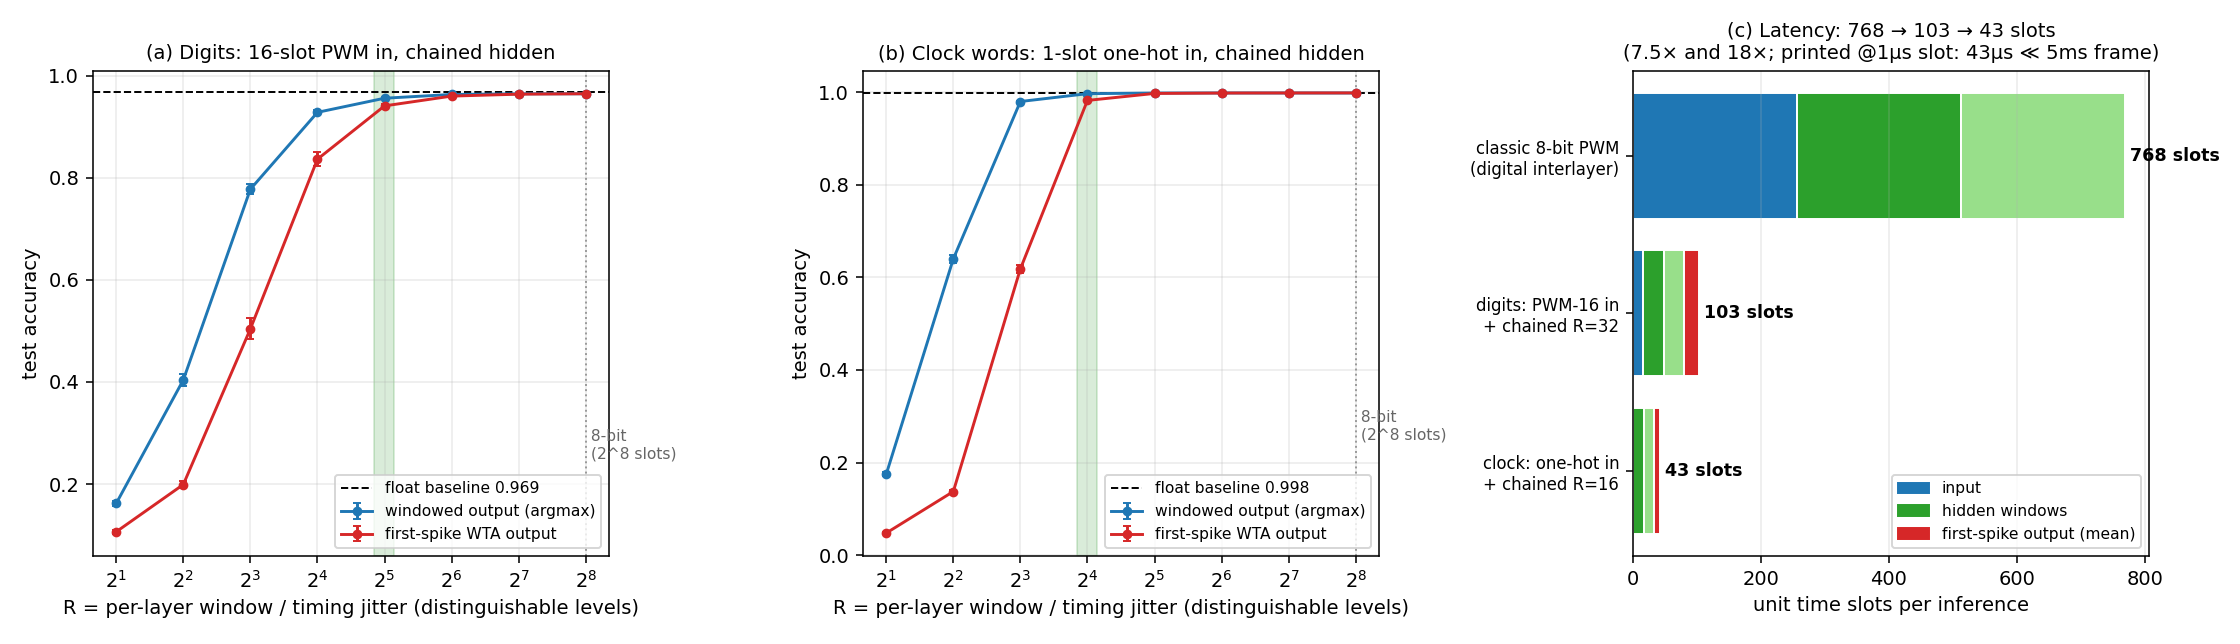

### die_preview.png
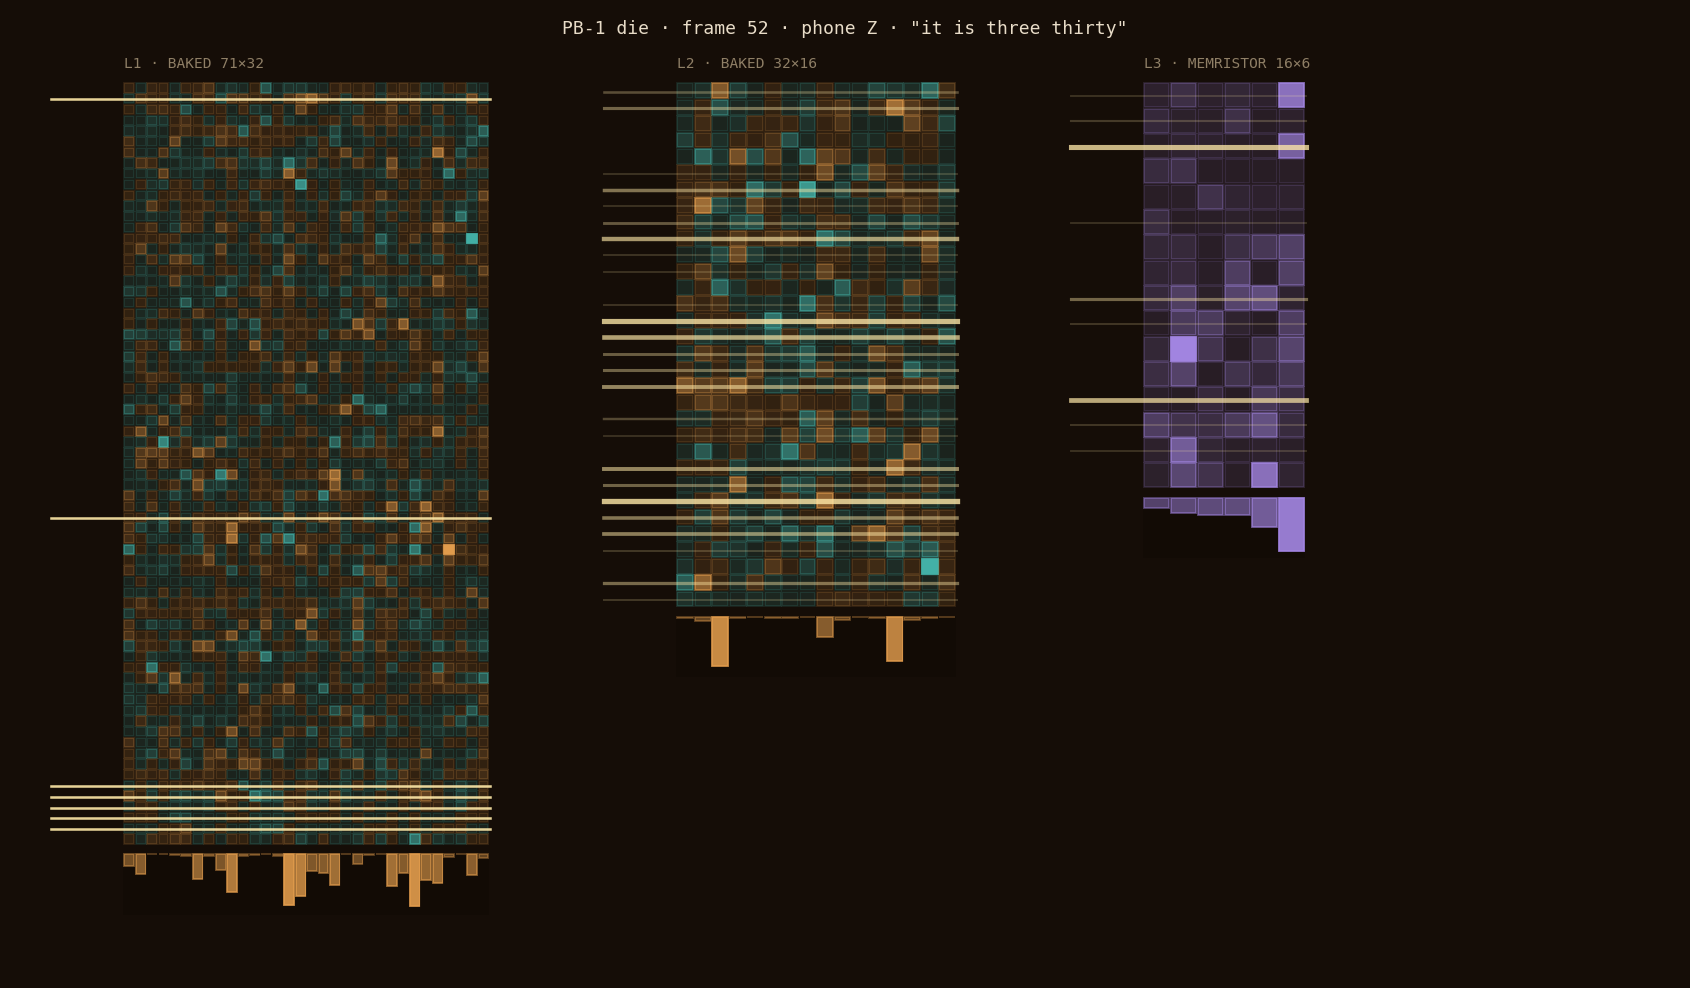